In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import CountVectorizer

In [2]:
df_10k = pd.read_csv("/Users/huss/data-processing/Github/Feminist-Literature-Engine-ML-Web-Scraping-App-/1_sources/API_Journal Articles_10k_Titles_Authors_Year_Topic_Publisher.csv", header=0, index_col=0)
df_10k
df_20k = pd.read_csv("/Users/huss/data-processing/Github/Feminist-Literature-Engine-ML-Web-Scraping-App-/1_sources/API_Journal Articles_20k_Titles_Authors_Year_Topic_Publisher.csv", header=0, index_col=0)
df_20k
df_60k = pd.read_csv("/Users/huss/data-processing/Github/Feminist-Literature-Engine-ML-Web-Scraping-App-/1_sources/API_60k_openalex_publications.csv", header=0, index_col=0)

df = pd.concat([df_10k, df_20k, df_60k], axis=0)
df

,Title,Year,Citations,Authors,AuthorOrder,Venue,AbstractInvertedIndex,AbstractText,Publisher,OpenAccess,...,Topics,Domain,Field,Subfield,Institutions,Languages,WorkType,DOI,LandingPage,PDFURL
ID,,,,,,,,,,,,,,,,,,,,,
1,Gender Trouble: Feminism and the Subversion of...,1991.0,28049,Mary McIntosh; Judith Butler,1. Mary McIntosh; 2. Judith Butler,Feminist Review,"{""Preface"": [0, 2], ""(1999)"": [1], ""(1990)"": [...",Preface (1999) Preface (1990) 1. Subjects of S...,SAGE Publishing,False,...,Latin American and Latino Studies; Anarchism a...,Social Sciences,Social Sciences,Cultural Studies,NaN,en,article,https://doi.org/10.2307/1395391,https://doi.org/10.2307/1395391,NaN
2,Situated Knowledges: The Science Question in F...,1988.0,17241,Donna Haraway,1. Donna Haraway,Feminist Studies,NaN,NaN,Feminist Studies,False,...,Feminist Epistemology and Gender Studies; Cont...,Social Sciences,Social Sciences,Sociology and Political Science,NaN,en,article,https://doi.org/10.2307/3178066,https://doi.org/10.2307/3178066,NaN
3,Gender trouble: feminism and the subversion of...,1990.0,7755,NaN,NaN,Choice Reviews Online,NaN,NaN,Association of College and Research Libraries,False,...,Gender Politics and Representation; Historical...,Social Sciences,Social Sciences,Gender Studies,NaN,en,article,https://doi.org/10.5860/choice.28-1264,https://doi.org/10.5860/choice.28-1264,NaN
4,Situated Knowledges: The Science Question in F...,1988.0,7010,Donna Haraway,1. Donna Haraway,PhilPapers (PhilPapers Foundation),"{""Academic"": [0], ""and"": [1, 23, 34, 44, 60, 6...",Academic and activist feminist inquiry has rep...,NaN,True,...,Interdisciplinary Research and Collaboration; ...,Social Sciences,Decision Sciences,Information Systems and Management,NaN,en,article,NaN,https://philarchive.org/rec/HARSKT,https://philpapers.org/archive/HARSKT.pdf
5,The science question in feminism,1987.0,3829,Kristin Waters,1. Kristin Waters,Women s Studies International Forum,NaN,NaN,Elsevier BV,False,...,Species Distribution and Climate Change; Susta...,Physical Sciences,Environmental Science,Ecological Modeling,NaN,en,article,https://doi.org/10.1016/0277-5395(87)90077-x,https://doi.org/10.1016/0277-5395(87)90077-x,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59996,To tell the right story,2013.0,13,Erik Eriksson,1. Erik Eriksson,Journal of Comparative Social Work,"{""From"": [0], ""the"": [1, 46, 68, 85, 89, 93, 1...",From the starting point of narrative ethnograp...,University of Stavanger,True,...,Mental Health and Patient Involvement; Mental ...,Health Sciences,Health Professions,General Health Professions,Lund University,en,article,https://doi.org/10.31265/jcsw.v8i2.103,https://doi.org/10.31265/jcsw.v8i2.103,https://journals.uis.no/index.php/JCSW/article...
59997,Generational Difference in Feminist Identities...,2009.0,0,Catherine E. Harnois,1. Catherine E. Harnois,DOAJ (DOAJ: Directory of Open Access Journals),"{""Studies"": [0], ""of"": [1, 34, 65, 84], ""the"":...",Studies of the general population have found s...,NaN,False,...,Youth Education and Societal Dynamics,Social Sciences,Social Sciences,Sociology and Political Science,NaN,en,article,NaN,https://doaj.org/article/c300e1880fe34eb6baf2d...,NaN
59998,Visionary Pragmatism and the Value of Privacy ...,2010.0,9,Danielle Keats Citron; Leslie Meltzer Henry,1. Danielle Keats Citron; 2. Leslie Meltzer Henry,Michigan Law Review,"{""Part"": [0, 83, 120], ""I"": [1], ""of"": [2, 9, ...",Part I of our Review discusses the central pre...,University of Michigan Law School,True,...,"Law, Rights, and Freedoms; Legal Systems and J...",Social Sciences,Social Sciences,Sociology and Political Science,NaN,en,article,https://doi.org/10.36644/mlr.108.6.visionary,https://doi.org/10.36644/mlr.108.6.visionary,NaN


In [3]:
df.columns = (
    df.columns
    .str.lower()
    .str.replace('(', '_', regex=False)   # replace ( with _
    .str.replace('/', '_', regex=False)   # replace ( with _
    .str.replace(')', '', regex=False)    # remove )
    .str.replace(r'[^\w\s]', '', regex=True)  # remove other special chars
    .str.replace(' ', '_')                # spaces → underscore
    .str.replace('__', '_')
)
df.columns



Index(['title', 'year', 'citations', 'authors', 'authororder', 'venue',
       'abstractinvertedindex', 'abstracttext', 'publisher', 'openaccess',
       'oastatus', 'referencedworks', 'relatedworks', 'concepts', 'topics',
       'domain', 'field', 'subfield', 'institutions', 'languages', 'worktype',
       'doi', 'landingpage', 'pdfurl'],
      dtype='object')

In [4]:
import numpy as np
#Explore all data
#print("\n", "Head:","\n", df.head(5))
#print("\n", "Tail:","\n", df.tail(5))
print("\n", "Null Values:","\n", df.isna().sum())




 Null Values: 
 title                       44
year                       109
citations                    0
authors                   3500
authororder               3500
venue                    12883
abstractinvertedindex    19808
abstracttext             19865
publisher                27358
openaccess                   0
oastatus                     0
referencedworks          43319
relatedworks              7783
concepts                   368
topics                     688
domain                     688
field                      688
subfield                   688
institutions             44620
languages                 1142
worktype                     0
doi                      17754
landingpage               1735
pdfurl                   58531
dtype: int64


In [5]:
df = df.drop(["pdfurl", "venue", "oastatus", "authororder", "abstractinvertedindex", "abstracttext", "publisher", "referencedworks", "institutions", "doi", "landingpage"], axis=1)
#df


In [6]:
print("\n", "Null Values:","\n", df.isna().sum())



 Null Values: 
 title             44
year             109
citations          0
authors         3500
openaccess         0
relatedworks    7783
concepts         368
topics           688
domain           688
field            688
subfield         688
languages       1142
worktype           0
dtype: int64


In [7]:
df = df.dropna(how="any")
df
print("\n", "Null Values:","\n", df.isna().sum())



 Null Values: 
 title           0
year            0
citations       0
authors         0
openaccess      0
relatedworks    0
concepts        0
topics          0
domain          0
field           0
subfield        0
languages       0
worktype        0
dtype: int64


## Sampling papers (to reduce number because the kernel keeps crashing, 80k is too much)

In [8]:
import pandas as pd

# df is your existing DataFrame with all 80k papers
# n is how many random papers you want
n = 25000
seed = 42

df = df.sample(n=n, random_state=seed)

# Save or use the subset
print(f"Saved {len(df)} randomly chosen papers")

Saved 25000 randomly chosen papers


In [9]:
print("\n", "Info:","\n", df.info())
#print("\n", "Info Memory Usage:","\n", df.info(memory_usage="deep"))


<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 636 to 1243
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         25000 non-null  object 
 1   year          25000 non-null  float64
 2   citations     25000 non-null  int64  
 3   authors       25000 non-null  object 
 4   openaccess    25000 non-null  bool   
 5   relatedworks  25000 non-null  object 
 6   concepts      25000 non-null  object 
 7   topics        25000 non-null  object 
 8   domain        25000 non-null  object 
 9   field         25000 non-null  object 
 10  subfield      25000 non-null  object 
 11  languages     25000 non-null  object 
 12  worktype      25000 non-null  object 
dtypes: bool(1), float64(1), int64(1), object(10)
memory usage: 2.5+ MB

 Info: 
 None


In [10]:
print("\n", "Describe:","\n", df.describe())
print("\n", "Describe All:","\n", df.describe(include="all"))
print("\n", "Shape:","\n", df.shape)
print("\n", "DTypes:","\n", df.dtypes)
print("\n", "Columns:","\n", df.columns)
#print("\n", "Index:","\n", df.index)
print("\n", "Values:","\n", df.values)
print("\n", "Empty:","\n", df.empty)
#print("\n", "NDim:","\n", df.ndim)
print("\n", "Size:","\n", df.size)
#print("\n", "Memory True:","\n", df.memory_usage(deep=True))
#print("\n", "Transpose:","\n", df.T)


 Describe: 
                year     citations
count  25000.000000  25000.000000
mean    2011.374040     30.611400
std       11.047018    270.161857
min     1814.000000      0.000000
25%     2005.000000      1.000000
50%     2015.000000      4.000000
75%     2020.000000     23.000000
max     2026.000000  28038.000000

 Describe All: 
                title          year     citations      authors openaccess  \
count          25000  25000.000000  25000.000000        25000      25000   
unique         24524           NaN           NaN        21381          2   
top     Introduction           NaN           NaN  Karen Offen      False   
freq              52           NaN           NaN           14      14807   
mean             NaN   2011.374040     30.611400          NaN        NaN   
std              NaN     11.047018    270.161857          NaN        NaN   
min              NaN   1814.000000      0.000000          NaN        NaN   
25%              NaN   2005.000000      1.000000      

In [11]:
#split cols into different columns 
numerical_cols = df.select_dtypes(include=np.number)
print(numerical_cols)

#be careful because some categorical values my sip into numerical_cols (numbers that represent category)
categorical_cols = df.select_dtypes(exclude=np.number)
print(categorical_cols)

         year  citations
ID                      
636    1992.0          1
11710  1995.0          8
8658   1976.0          5
57319  2010.0         11
23202  2008.0          0
...       ...        ...
10345  2024.0          0
23199  2012.0          6
52270  2021.0         36
1645   2019.0          2
1243   1995.0          4

[25000 rows x 2 columns]
                                                   title  \
ID                                                         
636    Book Reviews: John Piper and Wayne Grudem, edi...   
11710                        Feminist Psychopharmacology   
8658             Marxist Women versus Bourgeois Feminism   
57319  Rape, sexual politics and the construction of ...   
23202  Feminism, citizenship and social activity : th...   
...                                                  ...   
10345                      Feminism and Modern Sexuality   
23199                                       Introduction   
52270  Diversidade sexual: uma leitura do impacto

In [12]:
df["year"] = df["year"].astype(int)
df.head()


,title,year,citations,authors,openaccess,relatedworks,concepts,topics,domain,field,subfield,languages,worktype
ID,,,,,,,,,,,,,
636,"Book Reviews: John Piper and Wayne Grudem, edi...",1992,1,T.R. Hobbs,False,https://openalex.org/W2748952813; https://open...,Feminism; Religious studies; Theology; Sociolo...,"Religion, Society, and Development",Social Sciences,Social Sciences,Sociology and Political Science,en,article
11710,Feminist Psychopharmacology,1995,8,Marianne Marsh,False,https://openalex.org/W2022249999; https://open...,Empathy; Feminism; Countertransference; Empowe...,Sex and Gender in Healthcare; Mentoring and Ac...,Health Sciences,Medicine,"Public Health, Environmental and Occupational ...",en,article
8658,Marxist Women versus Bourgeois Feminism,1976,5,Hal Draper; Anne Grodzins Lipow,False,https://openalex.org/W2500929699; https://open...,Marxist philosophy; Bourgeoisie; Notice; Socio...,Political Economy and Marxism; Historical Gend...,Social Sciences,Social Sciences,Sociology and Political Science,en,article
57319,"Rape, sexual politics and the construction of ...",2010,11,Pascah Mungwini; Kudzai Matereke,True,https://openalex.org/W2748952813; https://open...,Shona; Gender studies; Human sexuality; Domina...,African Sexualities and LGBTQ+ Issues; Sex wor...,Social Sciences,Social Sciences,Sociology and Political Science,en,article
23202,"Feminism, citizenship and social activity : th...",2008,0,Samantha Ruth Clements,True,https://openalex.org/W596437143; https://opena...,Suffrage; Feminism; Redress; Context (archaeol...,"Historical Studies on Reproduction, Gender, He...",Social Sciences,Arts and Humanities,History,en,dissertation


In [13]:
print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nFirst 3 rows:")
df.head(3)

Shape: (25000, 13)

Column names:
 ['title', 'year', 'citations', 'authors', 'openaccess', 'relatedworks', 'concepts', 'topics', 'domain', 'field', 'subfield', 'languages', 'worktype']

Data types:
 title           object
year             int64
citations        int64
authors         object
openaccess        bool
relatedworks    object
concepts        object
topics          object
domain          object
field           object
subfield        object
languages       object
worktype        object
dtype: object

First 3 rows:


,title,year,citations,authors,openaccess,relatedworks,concepts,topics,domain,field,subfield,languages,worktype
ID,,,,,,,,,,,,,
636,"Book Reviews: John Piper and Wayne Grudem, edi...",1992,1,T.R. Hobbs,False,https://openalex.org/W2748952813; https://open...,Feminism; Religious studies; Theology; Sociolo...,"Religion, Society, and Development",Social Sciences,Social Sciences,Sociology and Political Science,en,article
11710,Feminist Psychopharmacology,1995,8,Marianne Marsh,False,https://openalex.org/W2022249999; https://open...,Empathy; Feminism; Countertransference; Empowe...,Sex and Gender in Healthcare; Mentoring and Ac...,Health Sciences,Medicine,"Public Health, Environmental and Occupational ...",en,article
8658,Marxist Women versus Bourgeois Feminism,1976,5,Hal Draper; Anne Grodzins Lipow,False,https://openalex.org/W2500929699; https://open...,Marxist philosophy; Bourgeoisie; Notice; Socio...,Political Economy and Marxism; Historical Gend...,Social Sciences,Social Sciences,Sociology and Political Science,en,article


In [14]:
#Count Unique values 
print("\n", df["year"].value_counts().sum)
print("\n", df["openaccess"].value_counts().sum)
print("\n", df["languages"].value_counts().sum)
print("\n", df["worktype"].value_counts().sum)
print("\n", df["domain"].value_counts().sum)
print("\n", df["field"].value_counts().sum)


 <bound method Series.sum of year
2020    1435
2019    1398
2018    1361
2021    1307
2023    1281
        ... 
1915       1
1814       1
1964       1
1927       1
1900       1
Name: count, Length: 84, dtype: int64>

 <bound method Series.sum of openaccess
False    14807
True     10193
Name: count, dtype: int64>

 <bound method Series.sum of languages
en     24002
es       279
fr       186
pt       159
id       100
de        90
it        21
tr        21
sv        17
pl        15
ar        12
ru         9
ca         8
ko         7
nl         7
hr         6
he         4
fi         4
cs         4
no         4
zh         3
sr         3
ms         3
af         3
da         3
la         2
sl         2
mk         2
ceb        2
ja         2
sk         2
uk         2
hu         1
sw         1
lt         1
eu         1
lv         1
el         1
th         1
ku         1
yi         1
eo         1
fa         1
pms        1
ro         1
et         1
tl         1
ne         1
Name: count, dtype: i

In [15]:
#### TITLE ANALYSIS

In [66]:
from sklearn.feature_extraction.text import CountVectorizer

titles = df['title'].dropna().astype(str)

vectorizer = CountVectorizer(
    stop_words='english',     # removes common words automatically
    ngram_range=(1, 2),       # counts single words AND two-word phrases
    max_features=20000           # top 50 most frequent terms
)

X = vectorizer.fit_transform(titles)

# Sum occurrences of each word across all titles
word_counts = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': X.toarray().sum(axis=0)
}).sort_values('count', ascending=False)

word_counts.to_csv("/Users/huss/data-processing/Github/Feminist-Literature-Engine-ML-Web-Scraping-App-/2_notebooks/1.3_title_concept_Topic_analysis/Title_original_word_Count.csv", index=False)

print(word_counts.head(5000))

                         word  count
6257                 feminism  10741
19354                   women   3926
7456                 feminist   2528
8335                   gender   2306
13937                politics   1069
...                       ...    ...
3423   conversations feminism      7
18858             video games      7
11934                  miriam      7
11849                mexicana      7
3381            contradictory      7

[5000 rows x 2 columns]


In [94]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# Your existing code
titles = df['title'].dropna().astype(str)

vectorizer = CountVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    max_features=20000
)

X = vectorizer.fit_transform(titles)

# Sum occurrences of each word across all titles
word_counts = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': X.toarray().sum(axis=0)
}).sort_values('count', ascending=False)

# Define category mapping dictionary
category_map = {
    # Core feminism category
    'feminism': 'feminism',
    'feminist': 'feminism',
    'feminisms': 'feminism',
    'feminists': 'feminism',
    'feminisme': 'feminism',
    'feminismo': 'feminism',
    'feminist theory': 'feminism theory',
    'radical feminism': 'radical feminism',
    'liberal feminism': 'liberal feminism',
    'black feminism': 'black feminism',
    'eco feminism': 'eco feminism',
    'islamic feminism': 'islamic feminism',
    'transnational feminism': 'transnational feminism',
    'american feminism': 'american feminism',
    'state feminism': 'state feminism',
    'post feminism': 'post feminism',
    
    # Women & Gender category
    'women': 'women gender',
    'woman': 'women gender',
    'female': 'women gender',
    'girls': 'women gender',
    'girl': 'women gender',
    'motherhood': 'women gender',
    'mothers': 'women gender',
    'mother': 'women gender',
    'maternal': 'women gender',
    'feminine': 'women gender',
    'femininity': 'women gender',
    'gender': 'women gender',
    'gendered': 'women gender',
    'gender studies': 'women gender',
    'gender equality': 'women gender',
    'women rights': 'women gender',
    'women movement': 'women gender',
    'muslim women': 'women gender',
    'american women': 'women gender',
    'black women': 'black women',
    
    # Politics & Society category
    'politics': 'politics society',
    'political': 'politics society',
    'society': 'politics society',
    'sociology': 'politics society',
    'social': 'politics society',
    'socialism': 'politics society',
    'socialist': 'politics society',
    'social justice': 'politics society',
    'social change': 'politics society',
    'social work': 'politics society',
    'social media': 'politics society',
    'civil': 'politics society',
    'citizenship': 'politics society',
    'community': 'politics society',
    'communities': 'politics society',
    'public': 'politics society',
    'state': 'politics society',
    'states': 'politics society',
    'nation': 'politics society',
    'national': 'politics society',
    'nationalism': 'politics society',
    'governance': 'politics society',
    'democracy': 'politics society',
    'rights': 'politics society',
    'human rights': 'politics society',
    'equality': 'politics society',
    'equity': 'politics society',
    'justice': 'politics society',
    'power': 'politics society',
    'ideology': 'politics society',
    'activism': 'politics society',
    'movement': 'politics society',
    'movements': 'politics society',
    'resistance': 'politics society',
    'struggle': 'politics society',
    'revolution': 'politics society',
    'liberation': 'politics society',
    'empowerment': 'politics society',
    'solidarity': 'politics society',
    'peace': 'politics society',
    'conflict': 'politics society',
    'war': 'politics society',
    'violence': 'politics society',
    'sexual violence': 'politics society',
    'abuse': 'politics society',
    'rape': 'politics society',
    'sexism': 'politics society',
    'racism': 'politics society',
    'critical race': 'politics society',
    'patriarchy': 'politics society',
    'masculinity': 'politics society',
    'masculinities': 'politics society',
    'male': 'politics society',
    'man': 'politics society',
    'men': 'politics society',
    
    # Identity & Culture category
    'identity': 'identity culture',
    'identities': 'identity culture',
    'culture': 'identity culture',
    'cultural': 'identity culture',
    'art': 'identity culture',
    'arts': 'identity culture',
    'literature': 'identity culture',
    'literary': 'identity culture',
    'film': 'identity culture',
    'cinema': 'identity culture',
    'music': 'identity culture',
    'popular culture': 'identity culture',
    'media': 'identity culture',
    'representation': 'identity culture',
    'representations': 'identity culture',
    'image': 'identity culture',
    'images': 'identity culture',
    'writing': 'identity culture',
    'writers': 'identity culture',
    'novel': 'identity culture',
    'novels': 'identity culture',
    'fiction': 'identity culture',
    'stories': 'identity culture',
    'story': 'identity culture',
    'narrative': 'identity culture',
    'narratives': 'identity culture',
    'voice': 'identity culture',
    'voices': 'identity culture',
    'discourse': 'identity culture',
    'discourses': 'identity culture',
    'book': 'identity culture',
    'books': 'identity culture',
    'press': 'identity culture',
    'university press': 'identity culture',
    
    # Race & Ethnicity category
    'race': 'race ethnicity',
    'black': 'race ethnicity',
    'white': 'race ethnicity',
    'african': 'race ethnicity',
    'indigenous': 'race ethnicity',
    'colonial': 'race ethnicity',
    'postcolonial': 'race ethnicity',
    'decolonial': 'race ethnicity',
    
    # Sexuality category
    'sexuality': 'sexuality',
    'sexual': 'sexuality',
    'sex': 'sexuality',
    'queer': 'sexuality',
    'lesbian': 'sexuality',
    'gay': 'sexuality',
    'trans': 'sexuality',
    
    # Intersectionality category
    'intersectionality': 'intersectionality',
    'intersectional': 'intersectionality',
    
    # Theory & Philosophy category
    'theory': 'theory philosophy',
    'theories': 'theory philosophy',
    'theoretical': 'theory philosophy',
    'theorizing': 'theory philosophy',
    'philosophy': 'theory philosophy',
    'ethics': 'theory philosophy',
    'ethical': 'theory philosophy',
    'psychoanalysis': 'theory philosophy',
    'foucault': 'theory philosophy',
    'marxism': 'theory philosophy',
    'marxist': 'theory philosophy',
    'neoliberal': 'theory philosophy',
    'neoliberalism': 'theory philosophy',
    'postmodern': 'theory philosophy',
    'postmodernism': 'theory philosophy',
    'modern': 'theory philosophy',
    'modernity': 'theory philosophy',
    'critical': 'theory philosophy',
    'critique': 'theory philosophy',
    'criticism': 'theory philosophy',
    'radical': 'theory philosophy',
    'liberal': 'theory philosophy',
    'change': 'theory philosophy',
    'changing': 'theory philosophy',
    'transformation': 'theory philosophy',
    'development': 'theory philosophy',
    'practice': 'theory philosophy',
    'practices': 'theory philosophy',
    'praxis': 'theory philosophy',
    'pedagogy': 'theory philosophy',
    'teaching': 'theory philosophy',
    'learning': 'theory philosophy',
    'education': 'theory philosophy',
    'higher education': 'theory philosophy',
    'university': 'theory philosophy',
    'academic': 'theory philosophy',
    'scholarship': 'theory philosophy',
    'research': 'theory philosophy',
    'study': 'theory philosophy',
    'studies': 'theory philosophy',
    'analysis': 'theory philosophy',
    'approach': 'theory philosophy',
    'approaches': 'theory philosophy',
    'methodology': 'theory philosophy',
    'qualitative': 'theory philosophy',
    'case study': 'theory philosophy',
    'case': 'theory philosophy',
    
    # Religion category
    'religion': 'religion',
    'religious': 'religion',
    'islam': 'religion',
    'islamic': 'religion',
    'christian': 'religion',
    'jewish': 'religion',
    'theology': 'religion',
    
    # Health category
    'health': 'health',
    'medicine': 'health',
    'medical': 'health',
    'nursing': 'health',
    'body': 'health',
    'bodies': 'health',
    'reproduction': 'health',
    'reproductive': 'health',
    'abortion': 'health',
    
    # Economics category
    'economy': 'economics',
    'economic': 'economics',
    'economics': 'economics',
    'capitalism': 'economics',
    'labor': 'economics',
    'labour': 'economics',
    'work': 'economics',
    'working': 'economics',
    'career': 'economics',
    'management': 'economics',
    
    # Geography & Region category
    'american': 'geography region',
    'america': 'geography region',
    'united states': 'geography region',
    'africa': 'geography region',
    'europe': 'geography region',
    'european': 'geography region',
    'england': 'geography region',
    'britain': 'geography region',
    'british': 'geography region',
    'uk': 'geography region',
    'london': 'geography region',
    'france': 'geography region',
    'french': 'geography region',
    'china': 'geography region',
    'chinese': 'geography region',
    'india': 'geography region',
    'indian': 'geography region',
    'australia': 'geography region',
    'australian': 'geography region',
    'canada': 'geography region',
    'canadian': 'geography region',
    'new york': 'geography region',
    'global': 'geography region',
    'international': 'geography region',
    'transnational': 'geography region',
    'urban': 'geography region',
    'rural': 'geography region',
    'city': 'geography region',
    
    # Time & Period category
    'contemporary': 'time period',
    'post': 'time period',
    'postmodern': 'time period',
    'postcolonial': 'time period',
    'victorian': 'time period',
    'twentieth': 'time period',
    'twentieth century': 'time period',
    'century': 'time period',
    'era': 'time period',
    'wave': 'time period',
    'wave feminism': 'time period',
    'second wave': 'time period',
    
    # Psychology category
    'psychology': 'psychology',
    'consciousness': 'psychology',
    'self': 'psychology',
    
    # Technology category
    'technology': 'technology',
    'digital': 'technology',
    'online': 'technology',
    
    # Environment category
    'environmental': 'environment',
    'climate': 'environment',
    'nature': 'environment',
}

# Create a function to map words to categories
def map_to_category(word):
    return category_map.get(word.lower(), 'other')

# Apply mapping to word_counts
word_counts['category'] = word_counts['word'].apply(map_to_category)

# Get top 5 words per category
top_words_per_category = {}
for category in word_counts['category'].unique():
    category_words = word_counts[word_counts['category'] == category].sort_values('count', ascending=False).head(5)
    top_words_per_category[category] = category_words

# Create a function to get top 5 words and counts for a given category
def get_top_words_for_category(category):
    """Returns dict with word_1, count_1, word_2, count_2, ..., word_5, count_5"""
    result = {}
    if category in top_words_per_category:
        category_data = top_words_per_category[category]
        for i, (idx, row) in enumerate(category_data.iterrows()):
            if i < 5:
                result[f'word_{i+1}'] = row['word']
                result[f'count_{i+1}'] = row['count']
        # Fill remaining with empty/0 if less than 5 words
        for i in range(len(category_data) + 1, 6):
            result[f'word_{i}'] = ''
            result[f'count_{i}'] = 0
    else:
        # If category not found, fill all with empty/0
        for i in range(1, 6):
            result[f'word_{i}'] = ''
            result[f'count_{i}'] = 0
    return result

# CORRECTED: Function to get title category
def get_title_category(title):
    """Find the category of the most frequent word in the title"""
    title_lower = title.lower()
    words_in_title = title_lower.split()
    
    # Find words that exist in our word_counts
    matched_words = []
    for i, word in enumerate(words_in_title):
        # Check single word
        match = word_counts[word_counts['word'] == word]
        if len(match) > 0:
            matched_words.append((word, match['count'].values[0], match['category'].values[0]))
        
        # Check two-word phrases
        if i < len(words_in_title) - 1:
            phrase = f"{word} {words_in_title[i+1]}"
            match = word_counts[word_counts['word'] == phrase]
            if len(match) > 0:
                matched_words.append((phrase, match['count'].values[0], match['category'].values[0]))
    
    # Return category of most frequent word
    if matched_words:
        best_match = max(matched_words, key=lambda x: x[1])
        return best_match[2]
    else:
        return 'uncategorized'

# Add category column to original df
df_with_category = df.copy()
df_with_category['title_category'] = df_with_category['title'].apply(get_title_category)

# Add top 5 words and counts for each title's category
def add_top_words_to_row(category):
    """Add word_1, count_1, ..., word_5, count_5 columns based on category"""
    row_dict = {}
    top_words = get_top_words_for_category(category)
    for key, value in top_words.items():
        row_dict[key] = value
    return row_dict

# Create a DataFrame with all top words columns
top_words_columns = pd.DataFrame(
    df_with_category['title_category'].apply(add_top_words_to_row).tolist(),
    index=df_with_category.index
)

# Combine original df with top words columns
final_df = pd.concat([df_with_category, top_words_columns], axis=1)

# Save outputs
# Save original word counts
original_path = "/Users/huss/data-processing/Github/Feminist-Literature-Engine-ML-Web-Scraping-App-/2_notebooks/1.3_title_concept_Topic_analysis/Title_word_Count.csv"
word_counts.to_csv(original_path, index=False)
print(f"Original word counts saved to: {original_path}")

# Save final dataframe with ALL original columns + 11 new columns
final_path = "/Users/huss/data-processing/Github/Feminist-Literature-Engine-ML-Web-Scraping-App-/2_notebooks/1.3_title_concept_Topic_analysis/Title_with_Top5_Words.csv"
final_df.to_csv(final_path, index=False)
print(f"Final dataframe with top 5 words saved to: {final_path}")

print(f"\n=== ORIGINAL DF COLUMNS: {len(df.columns)} ===")
print(df.columns.tolist())

print(f"\n=== FINAL DF COLUMNS: {len(final_df.columns)} ===")
print(final_df.columns.tolist())

print(f"\n=== TOTAL ROWS: {len(final_df)} ===")
print(f"\n=== SAMPLE (first 5 rows): ===")
print(final_df.head(5))

print("\n=== WORD COUNTS (first 5000) ===")
print(word_counts.head(5000))

print("\n=== CATEGORY DISTRIBUTION ===")
print(final_df['title_category'].value_counts())


Original word counts saved to: /Users/huss/data-processing/Github/Feminist-Literature-Engine-ML-Web-Scraping-App-/2_notebooks/1.3_title_concept_Topic_analysis/Title_word_Count.csv
Final dataframe with top 5 words saved to: /Users/huss/data-processing/Github/Feminist-Literature-Engine-ML-Web-Scraping-App-/2_notebooks/1.3_title_concept_Topic_analysis/Title_with_Top5_Words.csv

=== ORIGINAL DF COLUMNS: 14 ===
['title', 'year', 'citations', 'authors', 'openaccess', 'relatedworks', 'concepts', 'topics', 'domain', 'field', 'subfield', 'languages', 'worktype', 'main_field']

=== FINAL DF COLUMNS: 25 ===
['title', 'year', 'citations', 'authors', 'openaccess', 'relatedworks', 'concepts', 'topics', 'domain', 'field', 'subfield', 'languages', 'worktype', 'main_field', 'title_category', 'word_1', 'count_1', 'word_2', 'count_2', 'word_3', 'count_3', 'word_4', 'count_4', 'word_5', 'count_5']

=== TOTAL ROWS: 25000 ===

=== SAMPLE (first 5 rows): ===
                                                  

In [96]:
df['title_category'] = final_df['title_category']
df

,title,year,citations,authors,openaccess,relatedworks,concepts,topics,domain,field,subfield,languages,worktype,main_field,title_category
ID,,,,,,,,,,,,,,,
636,"Book Reviews: John Piper and Wayne Grudem, edi...",1992,1,T.R. Hobbs,False,https://openalex.org/W2748952813; https://open...,Feminism; Religious studies; Theology; Sociolo...,"Religion, Society, and Development",Social Sciences,Social Sciences,Sociology and Political Science,en,article,Social Sciences,identity culture
11710,Feminist Psychopharmacology,1995,8,Marianne Marsh,False,https://openalex.org/W2022249999; https://open...,Empathy; Feminism; Countertransference; Empowe...,Sex and Gender in Healthcare; Mentoring and Ac...,Health Sciences,Medicine,"Public Health, Environmental and Occupational ...",en,article,Medicine,feminism
8658,Marxist Women versus Bourgeois Feminism,1976,5,Hal Draper; Anne Grodzins Lipow,False,https://openalex.org/W2500929699; https://open...,Marxist philosophy; Bourgeoisie; Notice; Socio...,Political Economy and Marxism; Historical Gend...,Social Sciences,Social Sciences,Sociology and Political Science,en,article,Social Sciences,feminism
57319,"Rape, sexual politics and the construction of ...",2010,11,Pascah Mungwini; Kudzai Matereke,True,https://openalex.org/W2748952813; https://open...,Shona; Gender studies; Human sexuality; Domina...,African Sexualities and LGBTQ+ Issues; Sex wor...,Social Sciences,Social Sciences,Sociology and Political Science,en,article,Social Sciences,politics society
23202,"Feminism, citizenship and social activity : th...",2008,0,Samantha Ruth Clements,True,https://openalex.org/W596437143; https://opena...,Suffrage; Feminism; Redress; Context (archaeol...,"Historical Studies on Reproduction, Gender, He...",Social Sciences,Arts and Humanities,History,en,dissertation,Arts and Humanities,politics society
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10345,Feminism and Modern Sexuality,2024,0,Victoria Hesford,False,https://openalex.org/W2094403418; https://open...,Feminism; Human sexuality; Gender studies; Soc...,Historical Gender and Feminism Studies,Social Sciences,Social Sciences,Sociology and Political Science,en,book-chapter,Social Sciences,feminism
23199,Introduction,2012,6,Geraldine Pratt; Victoria Rosner,False,https://openalex.org/W2899674914; https://open...,Vision; Centrality; The Imaginary; Hegemony; F...,Historical Gender and Feminism Studies; Gender...,Social Sciences,Social Sciences,Sociology and Political Science,en,book-chapter,Social Sciences,other
52270,Diversidade sexual: uma leitura do impacto do ...,2021,36,José Carlos Pacheco da Silva; Rodrigo Ribeiro ...,True,https://openalex.org/W2748952813; https://open...,Psychology,"LGBTQ Health, Identity, and Policy; Gender, Se...",Social Sciences,Psychology,Social Psychology,pt,article,Psychology,other


In [17]:
#### CONCEPTS ANALYSIS

In [68]:

titles = df['concepts'].dropna().astype(str)

vectorizer = CountVectorizer(
    stop_words='english',     # removes common words automatically
    ngram_range=(1, 2),       # counts single words AND two-word phrases
    max_features=500           # top 50 most frequent terms
)

X = vectorizer.fit_transform(titles)

# Sum occurrences of each word across all titles
word_counts = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': X.toarray().sum(axis=0)
}).sort_values('count', ascending=False)

word_counts.to_csv("/Users/huss/data-processing/Github/Feminist-Literature-Engine-ML-Web-Scraping-App-/2_notebooks/1.3_title_concept_Topic_analysis/Concept_og_word_Count.csv", index=False)


print(word_counts.head(30))

                  word  count
383            science  25820
425          sociology  22346
449            studies  21212
154             gender  18932
156     gender studies  18062
309          political  16488
311  political science  15213
138           feminism  15045
204                law  13901
289         philosophy  11144
337         psychology   9862
312           politics   9729
25                 art   8845
417             social   7195
68            computer   6754
170            history   6606
69    computer science   6163
117       epistemology   4618
302            physics   4539
21         archaeology   4186
467  studies sociology   4122
398        science law   4012
432   sociology gender   3551
5           aesthetics   3460
44             biology   3361
246        mathematics   3288
228        linguistics   3257
231         literature   3134
421     social science   3051
103          economics   2853


In [75]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# Use concepts column instead of title
concepts = df['concepts'].dropna().astype(str)

vectorizer = CountVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    max_features=20000
)

X = vectorizer.fit_transform(concepts)

# Sum occurrences of each word across all concepts
word_counts = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': X.toarray().sum(axis=0)
}).sort_values('count', ascending=False)

# Define category mapping dictionary for concepts
category_map = {
    # Science category
    # Science
    'science': 'science',
    'physics': 'science',
    'biology': 'science',
    'mathematics': 'science',
    'chemistry': 'science',
    'ecology': 'science',
    'biochemistry': 'science',
    'chemistry biochemistry': 'science',
    'biology ecology': 'science',
    'ecology biology': 'science',
    'genetics': 'science',
    'gene': 'science',
    'mutation': 'science',
    'paleontology': 'science',
    'astronomy': 'science',
    'quantum': 'science',
    'quantum mechanics': 'science',
    'mechanics': 'science',
    'mechanics physics': 'science',
    'physics quantum': 'science',
    'optics': 'science',
    'acoustics': 'science',
    'statistics': 'science',
    'mathematical': 'science',
    'mathematical analysis': 'science',
    'pure mathematics': 'science',
    'field mathematics': 'science',
    'character mathematics': 'science',
    'value mathematics': 'science',
    'geometry': 'science',
    'algorithm': 'science',
    'science algorithm': 'science',
    'science mathematics': 'science',
    'science biology': 'science',
    'science physics': 'science',
    'science chemistry': 'science',
    'science engineering': 'science',
    'science medicine': 'science',
    'science law': 'science',
    'science politics': 'science',
    'science philosophy': 'science',
    'science psychology': 'science',
    'science sociology': 'science',
    'science gender': 'science',
    'science art': 'science',
    'science history': 'science',
    'science archaeology': 'science',
    'science linguistics': 'science',
    'science literature': 'science',
    'science media': 'science',
    'science economics': 'science',
    'science anthropology': 'science',
    'science aesthetics': 'science',
    'science library': 'science',
    'science world': 'science',
    'science artificial': 'science',
    'science epistemology': 'science',
    'computer science': 'computer science',
    'computer': 'computer science',
    'programming': 'computer science',
    'programming language': 'computer science',
    'computer security': 'computer science',
    'computer science': 'computer science',
    'science computer': 'computer science',
    'state computer': 'computer science',
    'sociology computer': 'computer science',
    'psychology computer': 'computer science',
    'philosophy computer': 'computer science',
    'studies computer': 'computer science',
    'law computer': 'computer science',
    'internet': 'computer science',
    'web': 'computer science',
    'wide web': 'computer science',
    'world wide': 'computer science',
    'database': 'computer science',
    'relation database': 'computer science',
    'machine': 'computer science',
    'machine learning': 'computer science',
    'computing': 'computer science',
    'operating': 'computer science',
    'cybernetics': 'computer science',
    'variety cybernetics': 'computer science',
    
    # Social Sciences
    'sociology': 'social sciences',
    'social science': 'social sciences',
    'social sciences': 'social sciences',
    'social': 'social sciences',
    'psychology': 'social sciences',
    'social psychology': 'social sciences',
    'psychology social': 'social sciences',
    'sociology social': 'social sciences',
    'social movement': 'social sciences',
    'sociological': 'social sciences',
    'sociological concept': 'social sciences',
    'face sociological': 'social sciences',
    'epistemology social': 'social sciences',
    'politics social': 'social sciences',
    'law social': 'social sciences',
    'sociology': 'social sciences',
    'anthropology': 'social sciences',
    'criminology': 'social sciences',
    'demography': 'social sciences',
    'population': 'social sciences',
    'group': 'social sciences',
    'ethnic group': 'social sciences',
    'ethnic': 'social sciences',
    'race': 'social sciences',
    'racism': 'social sciences',
    'race biology': 'social sciences',
    'white': 'social sciences',
    'black': 'social sciences',
    'black feminism': 'social sciences',
    'indigenous': 'social sciences',
    'diversity': 'social sciences',
    'multiculturalism': 'social sciences',
    'inclusion': 'social sciences',
    'equality': 'social sciences',
    'equity': 'social sciences',
    'justice': 'social sciences',
    'economic justice': 'social sciences',
    'human rights': 'social sciences',
    'rights': 'social sciences',
    'citizenship': 'social sciences',
    'government': 'social sciences',
    'public administration': 'social sciences',
    'administration': 'social sciences',
    'state': 'social sciences',
    'order': 'social sciences',
    'exchange': 'social sciences',
    'order exchange': 'social sciences',
    'capitalism': 'social sciences',
    'communism': 'social sciences',
    'socialism': 'social sciences',
    'liberalism': 'social sciences',
    'neoliberalism': 'social sciences',
    'neoliberalism international': 'social sciences',
    'marxist': 'social sciences',
    'marxist philosophy': 'social sciences',
    'materialism': 'social sciences',
    'class': 'social sciences',
    'class philosophy': 'social sciences',
    'inequality': 'social sciences',
    'oppression': 'social sciences',
    'empowerment': 'social sciences',
    'resistance': 'social sciences',
    'solidarity': 'social sciences',
    'emancipation': 'social sciences',
    'patriarchy': 'social sciences',
    'hegemony': 'social sciences',
    'power': 'social sciences',
    'violence': 'social sciences',
    'conflict': 'social sciences',
    'violence': 'social sciences',
    'suicide': 'social sciences',
    'suicide prevention': 'social sciences',
    'prevention': 'social sciences',
    'intervention': 'social sciences',
    'care': 'social sciences',
    'family': 'social sciences',
    'gender': 'gender studies',
    'gender studies': 'gender studies',
    'feminism': 'gender studies',
    'feminist': 'gender studies',
    'feminism gender': 'gender studies',
    'feminism sociology': 'gender studies',
    'feminism politics': 'gender studies',
    'feminism art': 'gender studies',
    'feminism political': 'gender studies',
    'feminist theory': 'gender studies',
    'feminist philosophy': 'gender studies',
    'feminist movement': 'gender studies',
    'studies feminism': 'gender studies',
    'studies feminist': 'gender studies',
    'sociology feminism': 'gender studies',
    'sociology feminist': 'gender studies',
    'politics feminism': 'gender studies',
    'queer': 'gender studies',
    'queer theory': 'gender studies',
    'sexuality': 'gender studies',
    'human sexuality': 'gender studies',
    'lesbian': 'gender studies',
    'transgender': 'gender studies',
    'girl': 'gender studies',
    'women': 'gender studies',
    'masculinity': 'gender studies',
    'femininity': 'gender studies',
    'gender equality': 'gender studies',
    'physics gender': 'gender studies',
    'philosophy gender': 'gender studies',
    'epistemology gender': 'gender studies',
    'psychology gender': 'gender studies',
    'sociology gender': 'gender studies',
    'science gender': 'gender studies',
    'law gender': 'gender studies',
    'art gender': 'gender studies',
    'music gender': 'gender studies',
    'international relations': 'international relations',
    'international': 'international relations',
    'relations': 'international relations',
    'relations political': 'international relations',
    'neoliberalism international': 'international relations',
    
    # Political Science
    'political science': 'political science',
    'political': 'political science',
    'politics': 'political science',
    'political economy': 'political science',
    'political economy': 'political science',
    'economy': 'political science',
    'economics': 'economics',
    'economic': 'economics',
    'economy law': 'economics',
    'law economics': 'economics',
    'science economics': 'economics',
    'finance': 'economics',
    'marketing': 'economics',
    'advertising': 'economics',
    'business': 'business',
    'management': 'business',
    'marketing': 'business',
    
    # Law
    'law': 'law',
    'legal': 'law',
    'law politics': 'law',
    'law political': 'law',
    'politics law': 'law',
    'law philosophy': 'law',
    'law art': 'law',
    'law biology': 'law',
    'law archaeology': 'law',
    'law physics': 'law',
    'law aesthetics': 'law',
    'law epistemology': 'law',
    'law psychology': 'law',
    'law sociology': 'law',
    'law sociology': 'law',
    'law linguistics': 'law',
    'law gender': 'law',
    'law history': 'law',
    'law economics': 'law',
    'law social': 'law',
    'law computer': 'law',
    'law anatomy': 'law',
    'science law': 'law',
    'studies law': 'law',
    'history law': 'law',
    'gender law': 'law',
    
    # Philosophy
    'philosophy': 'philosophy',
    'ethics': 'philosophy',
    'environmental ethics': 'philosophy',
    'engineering ethics': 'philosophy',
    'aesthetics': 'philosophy',
    'aesthetics art': 'philosophy',
    'aesthetics philosophy': 'philosophy',
    'aesthetics political': 'philosophy',
    'aesthetics sociology': 'philosophy',
    'aesthetics law': 'philosophy',
    'art aesthetics': 'philosophy',
    'sociology aesthetics': 'philosophy',
    'science aesthetics': 'philosophy',
    'epistemology': 'philosophy',
    'epistemology philosophy': 'philosophy',
    'epistemology political': 'philosophy',
    'epistemology psychology': 'philosophy',
    'epistemology sociology': 'philosophy',
    'epistemology social': 'philosophy',
    'epistemology law': 'philosophy',
    'epistemology gender': 'philosophy',
    'science epistemology': 'philosophy',
    'sociology epistemology': 'philosophy',
    'studies epistemology': 'philosophy',
    'philosophy epistemology': 'philosophy',
    'philosophy politics': 'philosophy',
    'philosophy law': 'philosophy',
    'philosophy psychology': 'philosophy',
    'philosophy art': 'philosophy',
    'philosophy archaeology': 'philosophy',
    'philosophy theology': 'philosophy',
    'philosophy computer': 'philosophy',
    'philosophy linguistics': 'philosophy',
    'philosophy gender': 'philosophy',
    'philosophy sociology': 'philosophy',
    'philosophy political': 'philosophy',
    'theology': 'philosophy',
    'theology philosophy': 'philosophy',
    'religion': 'philosophy',
    'religious': 'philosophy',
    'religious studies': 'philosophy',
    'islam': 'philosophy',
    'mythology': 'philosophy',
    'existential': 'philosophy',
    'meaning existential': 'philosophy',
    'existentialism': 'philosophy',
    'postmodernism': 'philosophy',
    'modernity': 'philosophy',
    'colonialism': 'philosophy',
    'critical': 'philosophy',
    'critical theory': 'philosophy',
    'criticism': 'philosophy',
    'agency': 'philosophy',
    'agency philosophy': 'philosophy',
    'subject': 'philosophy',
    'subjectivity': 'philosophy',
    'subject documents': 'philosophy',
    'consciousness': 'philosophy',
    'cognition': 'philosophy',
    'embodied cognition': 'philosophy',
    'cognitive': 'philosophy',
    'psychological': 'philosophy',
    'psychoanalysis': 'philosophy',
    'psychoanalysis psychology': 'philosophy',
    'psychoanalysis sociology': 'philosophy',
    'psychology psychoanalysis': 'philosophy',
    'studies psychoanalysis': 'philosophy',
    'narrative': 'philosophy',
    'framing': 'philosophy',
    'construction': 'philosophy',
    'framing construction': 'philosophy',
    'interpretation': 'philosophy',
    'interpretation philosophy': 'philosophy',
    'rhetoric': 'philosophy',
    'argument': 'philosophy',
    'argument complex': 'philosophy',
    'complex': 'philosophy',
    'complex analysis': 'philosophy',
    'variety': 'philosophy',
    'transformative': 'philosophy',
    'transformative learning': 'philosophy',
    'praxis': 'philosophy',
    'knowledge': 'philosophy',
    'value': 'philosophy',
    'meaning': 'philosophy',
    'feeling': 'philosophy',
    'perception': 'philosophy',
    'embodied': 'philosophy',
    'autonomy': 'philosophy',
    'freedom': 'philosophy',
    'power': 'philosophy',
    'ideology': 'philosophy',
    
    # Psychology
    'psychology': 'psychology',
    'social psychology': 'psychology',
    'psychology social': 'psychology',
    'developmental psychology': 'psychology',
    'developmental': 'psychology',
    'cognitive': 'psychology',
    'cognitive psychology': 'psychology',
    'neuropsychology': 'psychology',
    'neuroscience': 'psychology',
    'psychiatry': 'psychology',
    'psychotherapist': 'psychology',
    'mental health': 'psychology',
    'psychology political': 'psychology',
    'psychology law': 'psychology',
    'psychology art': 'psychology',
    'psychology epistemology': 'psychology',
    'psychology gender': 'psychology',
    'psychology philosophy': 'psychology',
    'psychology psychology': 'psychology',
    'sociology psychology': 'psychology',
    'psychology sociology': 'psychology',
    'studies psychology': 'psychology',
    
    # History
    'history': 'history',
    'art history': 'history',
    'history art': 'history',
    'history sociology': 'history',
    'history political': 'history',
    'history law': 'history',
    'history gender': 'history',
    'history archaeology': 'history',
    'history philosophy': 'history',
    'history literature': 'history',
    'ancient history': 'history',
    'studies history': 'history',
    'history history': 'history',
    'context archaeology': 'history',
    'archaeology': 'history',
    'archaeology sociology': 'history',
    'law archaeology': 'history',
    'science archaeology': 'history',
    'studies archaeology': 'history',
    
    # Literature
    'literature': 'literature',
    'literary': 'literature',
    'literature art': 'literature',
    'literature philosophy': 'literature',
    'literature sociology': 'literature',
    'art literature': 'literature',
    'science literature': 'literature',
    'studies literature': 'literature',
    'poetry': 'literature',
    'reading': 'literature',
    'reading process': 'literature',
    'narrative': 'literature',
    'movie': 'literature',
    'theater': 'literature',
    'movie theater': 'literature',
    
    # Arts
    'art': 'arts',
    'arts': 'arts',
    'visual arts': 'arts',
    'visual': 'arts',
    'art history': 'arts',
    'art sociology': 'arts',
    'art gender': 'arts',
    'art law': 'arts',
    'art philosophy': 'arts',
    'art politics': 'arts',
    'art political': 'arts',
    'art aesthetics': 'arts',
    'art psychology': 'arts',
    'art visual': 'arts',
    'art art': 'arts',
    'sociology art': 'arts',
    'studies art': 'arts',
    'history art': 'arts',
    'science art': 'arts',
    'law art': 'arts',
    'music': 'arts',
    'music gender': 'arts',
    'music sociology': 'arts',
    'movement music': 'arts',
    'identity music': 'arts',
    'acoustics': 'arts',
    'theater': 'arts',
    'movie': 'arts',
    'movie theater': 'arts',
    'poetry': 'arts',
    
    # Cultural Studies
    'cultural': 'cultural studies',
    'cultural studies': 'cultural studies',
    'culture': 'cultural studies',
    'popular culture': 'cultural studies',
    'identity': 'cultural studies',
    'representation': 'cultural studies',
    'representation politics': 'cultural studies',
    'ethnic': 'cultural studies',
    'diversity': 'cultural studies',
    'multiculturalism': 'cultural studies',
    
    # Education
    'education': 'education',
    'pedagogy': 'education',
    'learning': 'education',
    'transformative learning': 'education',
    'mathematics education': 'education',
    'studies education': 'education',
    
    # Media Studies
    'media': 'media studies',
    'media studies': 'media studies',
    'sociology media': 'media studies',
    'studies media': 'media studies',
    'science media': 'media studies',
    'social media': 'media studies',
    
    # Health
    'health': 'health',
    'medicine': 'health',
    'medical': 'health',
    'health care': 'health',
    'environmental health': 'health',
    'internal medicine': 'health',
    'nursing': 'health',
    'pathology': 'health',
    'disease': 'health',
    'pregnancy': 'health',
    'reproduction': 'health',
    'reproductive': 'health',
    'public health': 'health',
    'poison': 'health',
    'poison control': 'health',
    'control': 'health',
    'psychiatry': 'health',
    
    # Research
    'research': 'research',
    'qualitative': 'research',
    'qualitative research': 'research',
    'studies research': 'research',
    'scholarship': 'research',
    'science research': 'research',
}

# Create a function to map words to categories
def map_to_category(word):
    return category_map.get(word.lower(), 'other')

# Apply mapping to word_counts
word_counts['category'] = word_counts['word'].apply(map_to_category)

# Get top 5 words per category
top_words_per_category = {}
for category in word_counts['category'].unique():
    category_words = word_counts[word_counts['category'] == category].sort_values('count', ascending=False).head(5)
    top_words_per_category[category] = category_words

# Create a function to get top 5 words and counts for a given category
def get_top_words_for_category(category):
    """Returns dict with concept_word_1, concept_count_1, ..., concept_word_5, concept_count_5"""
    result = {}
    if category in top_words_per_category:
        category_data = top_words_per_category[category]
        for i, (idx, row) in enumerate(category_data.iterrows()):
            if i < 5:
                result[f'concept_word_{i+1}'] = row['word']
                result[f'concept_count_{i+1}'] = row['count']
        # Fill remaining with empty/0 if less than 5 words
        for i in range(len(category_data) + 1, 6):
            result[f'concept_word_{i}'] = ''
            result[f'concept_count_{i}'] = 0
    else:
        # If category not found, fill all with empty/0
        for i in range(1, 6):
            result[f'concept_word_{i}'] = ''
            result[f'concept_count_{i}'] = 0
    return result

# Function to get concept category
def get_topic_field(field):
    """Find the field category of the input field"""
    field_lower = field.lower().strip()
    
    # First, try exact match with the whole field string
    if field_lower in field_category_map:
        return field_category_map[field_lower]
    
    # Second, try splitting by space (if no pipes)
    if '|' not in field_lower:
        words = field_lower.split()
        # Try consecutive word pairs
        for i in range(len(words) - 1):
            phrase = f"{words[i]} {words[i+1]}"
            if phrase in field_category_map:
                return field_category_map[phrase]
        # Try single words
        for word in words:
            if word in field_category_map:
                return field_category_map[word]
    
    # Third, try splitting by pipe
    else:
        words = field_lower.split('|')
        # Try the whole phrase (already done above)
        # Try single words
        for word in words:
            word = word.strip()
            if word in field_category_map:
                return field_category_map[word]
    
    return 'uncategorized'

# Add category column to original df
df_with_category = df.copy()
df_with_category['concept_category'] = df_with_category['concepts'].apply(get_concept_category)

# Add top 5 words and counts for each concept's category
def add_top_words_to_row(category):
    """Add concept_word_1, concept_count_1, ..., concept_word_5, concept_count_5 columns based on category"""
    row_dict = {}
    top_words = get_top_words_for_category(category)
    for key, value in top_words.items():
        row_dict[key] = value
    return row_dict

# Create a DataFrame with all top words columns
top_words_columns = pd.DataFrame(
    df_with_category['concept_category'].apply(add_top_words_to_row).tolist(),
    index=df_with_category.index
)

# Combine original df with top words columns
final_df = pd.concat([df_with_category, top_words_columns], axis=1)

# Save outputs
# Save original word counts
original_path = "/Users/huss/data-processing/Github/Feminist-Literature-Engine-ML-Web-Scraping-App-/2_notebooks/1.3_title_concept_Topic_analysis/Concept_word_Count.csv"
word_counts.to_csv(original_path, index=False)
print(f"Original concept word counts saved to: {original_path}")

# Save final dataframe with ALL original columns + 11 new columns
final_path = "/Users/huss/data-processing/Github/Feminist-Literature-Engine-ML-Web-Scraping-App-/2_notebooks/1.3_title_concept_Topic_analysis/Concept_with_Top5_Words.csv"
final_df.to_csv(final_path, index=False)
print(f"Final dataframe with top 5 concept words saved to: {final_path}")

print(f"\n=== ORIGINAL DF COLUMNS: {len(df.columns)} ===")
print(df.columns.tolist())

print(f"\n=== FINAL DF COLUMNS: {len(final_df.columns)} ===")
print(final_df.columns.tolist())

print(f"\n=== TOTAL ROWS: {len(final_df)} ===")
print(f"\n=== SAMPLE (first 5 rows): ===")
print(final_df.head(5))

print("\n=== CONCEPT WORD COUNTS (first 5000) ===")
print(word_counts.head(5000))

print("\n=== CATEGORY DISTRIBUTION ===")
print(final_df['concept_category'].value_counts())


Original concept word counts saved to: /Users/huss/data-processing/Github/Feminist-Literature-Engine-ML-Web-Scraping-App-/2_notebooks/1.3_title_concept_Topic_analysis/Concept_word_Count.csv
Final dataframe with top 5 concept words saved to: /Users/huss/data-processing/Github/Feminist-Literature-Engine-ML-Web-Scraping-App-/2_notebooks/1.3_title_concept_Topic_analysis/Concept_with_Top5_Words.csv

=== ORIGINAL DF COLUMNS: 13 ===
['title', 'year', 'citations', 'authors', 'openaccess', 'relatedworks', 'concepts', 'topics', 'domain', 'field', 'subfield', 'languages', 'worktype']

=== FINAL DF COLUMNS: 24 ===
['title', 'year', 'citations', 'authors', 'openaccess', 'relatedworks', 'concepts', 'topics', 'domain', 'field', 'subfield', 'languages', 'worktype', 'concept_category', 'concept_word_1', 'concept_count_1', 'concept_word_2', 'concept_count_2', 'concept_word_3', 'concept_count_3', 'concept_word_4', 'concept_count_4', 'concept_word_5', 'concept_count_5']

=== TOTAL ROWS: 25000 ===

=== SAM

In [19]:
#### TOPICS ANALYSIS

In [97]:

titles = df['topics'].dropna().astype(str)

vectorizer = CountVectorizer(
    stop_words='english',     # removes common words automatically
    ngram_range=(1, 2),       # counts single words AND two-word phrases
    max_features=2000           # top 50 most frequent terms
)

X = vectorizer.fit_transform(titles)

# Sum occurrences of each word across all titles
word_counts = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': X.toarray().sum(axis=0)
}).sort_values('count', ascending=False)

word_counts.to_csv("/Users/huss/data-processing/Github/Feminist-Literature-Engine-ML-Web-Scraping-App-/2_notebooks/1.3_title_concept_Topic_analysis/Topic_og_word_Count.csv", index=False)


print(word_counts.head(5000))

                      word  count
1726               studies  14204
721                 gender  14172
677               feminism   5555
1124                 media   5299
840                history   4948
...                    ...    ...
1701            spaces art     18
31    advertising consumer     18
1282  participation social     18
720         garcía márquez     18
924             indonesian     18

[2000 rows x 2 columns]


In [21]:
#### DOMAIN ANALYSIS - Domain not needes as it is well categorized already

In [83]:
"""#!pip install spacy
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import spacy

# ============================
# 1. Setup lemmatization (to merge duplicates like feminism/feminist/feminisms)
# ============================
nlp = spacy.load("en_core_web_sm")

def normalize_text(text):
    """Lemmatize text and remove stops, returning normalized words."""
    doc = nlp(str(text).lower())
    tokens = [token.lemma_ for token in doc if not token.is_stop and token.lemma_.strip()]
    return " ".join(tokens)

# ============================
# 2. Use topics column instead of concepts
# ============================
topics = df['domain'].dropna().astype(str)
topics_normalized = topics.apply(normalize_text)

vectorizer = CountVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    max_features=20000
)

X = vectorizer.fit_transform(topics_normalized)

# Sum occurrences of each word across all topics
word_counts = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': X.toarray().sum(axis=0)
}).sort_values('count', ascending=False)

# ============================
# 3. Define category mapping dictionary for topics (normalized words)
# ============================
category_map = {
    # Science category
    'sciences': 'Natural Sciences',
    'social': 'Social Sciences',
    'social sciences': 'Social Sciences',
    'health': 'Health Sciences',
    'health sciences': 'Health Sciences',
    'physical': 'Physical Sciences',
    'physical sciences': 'Physical Sciences',
    'life': 'Life Sciences',
    'life sciences': 'Life Sciences',
}

# ============================
# 4. Create a function to map words to categories
# ============================
def map_to_category(word):
    return category_map.get(word.lower(), 'other')

# Apply mapping to word_counts
word_counts['category'] = word_counts['word'].apply(map_to_category)

# ============================
# 5. Get top 5 words per category
# ============================
top_words_per_category = {}
for category in word_counts['category'].unique():
    category_words = word_counts[word_counts['category'] == category].sort_values('count', ascending=False).head(5)
    top_words_per_category[category] = category_words

# ============================
# 6. Create a function to get top 5 words and counts for a given category
# ============================
def get_top_words_for_category(category):
    """Returns dict with topic_word_1, topic_count_1, ..., topic_word_5, topic_count_5"""
    result = {}
    if category in top_words_per_category:
        category_data = top_words_per_category[category]
        for i, (idx, row) in enumerate(category_data.iterrows()):
            if i < 5:
                result[f'topic_word_{i+1}'] = row['word']
                result[f'topic_count_{i+1}'] = row['count']
        # Fill remaining with empty/0 if less than 5 words
        for i in range(len(category_data) + 1, 6):
            result[f'topic_word_{i}'] = ''
            result[f'topic_count_{i}'] = 0
    else:
        # If category not found, fill all with empty/0
        for i in range(1, 6):
            result[f'topic_word_{i}'] = ''
            result[f'topic_count_{i}'] = 0
    return result

# ============================
# 7. Function to get topic category (using normalized topics)
# ============================
def get_topic_category(topic):
    """Find the category of the most frequent word in the topic"""
    topic_lower = topic.lower()
    words_in_topic = topic_lower.split('|')
    
    # Find words that exist in our word_counts
    matched_words = []
    for i, word in enumerate(words_in_topic):
        word = word.strip()
        # Check single word
        match = word_counts[word_counts['word'] == word]
        if len(match) > 0:
            matched_words.append((word, match['count'].values[0], match['category'].values[0]))
        
        # Check two-word phrases
        if i < len(words_in_topic) - 1:
            next_word = words_in_topic[i+1].strip()
            phrase = f"{word} {next_word}"
            match = word_counts[word_counts['word'] == phrase]
            if len(match) > 0:
                matched_words.append((phrase, match['count'].values[0], match['category'].values[0]))
    
    # Return category of most frequent word
    if matched_words:
        best_match = max(matched_words, key=lambda x: x[1])
        return best_match[2]
    else:
        return 'uncategorized'

# ============================
# 8. Add category column to original df
# ============================
df_with_category = df.copy()
df_with_category['topic_category'] = df_with_category['domain'].apply(get_topic_category)

# ============================
# 9. Add top 5 words and counts for each topic's category
# ============================
def add_top_words_to_row(category):
    """Add domain_word_1, domain_count_1, ..., domain_word_5, domain_count_5 columns based on category"""
    row_dict = {}
    top_words = get_top_words_for_category(category)
    for key, value in top_words.items():
        row_dict[key] = value
    return row_dict

# Create a DataFrame with all top words columns
top_words_columns = pd.DataFrame(
    df_with_category['topic_category'].apply(add_top_words_to_row).tolist(),
    index=df_with_category.index
)

# Combine original df with top words columns
final_df = pd.concat([df_with_category, top_words_columns], axis=1)

# ============================
# 10. Save outputs
# ============================
# Save original word counts
original_path = "/Users/huss/data-processing/Github/Feminist-Literature-Engine-ML-Web-Scraping-App-/2_notebooks/1.3_title_concept_Topic_analysis/domain_word_Count.csv"
word_counts.to_csv(original_path, index=False)
print(f"Original topic word counts saved to: {original_path}")

# Save final dataframe with ALL original columns + 11 new columns
final_path = "/Users/huss/data-processing/Github/Feminist-Literature-Engine-ML-Web-Scraping-App-/2_notebooks/1.3_title_concept_Topic_analysis/domain_with_Top5_Words.csv"
final_df.to_csv(final_path, index=False)
print(f"Final dataframe with top 5 topic words saved to: {final_path}")

print(f"\n=== ORIGINAL DF COLUMNS: {len(df.columns)} ===")
print(df.columns.tolist())

print(f"\n=== FINAL DF COLUMNS: {len(final_df.columns)} ===")
print(final_df.columns.tolist())

print(f"\n=== TOTAL ROWS: {len(final_df)} ===")
print(f"\n=== SAMPLE (first 5 rows): ===")
print(final_df.head(5))

print("\n=== TOPIC WORD COUNTS (first 5000) ===")
print(word_counts.head(5000))

print("\n=== CATEGORY DISTRIBUTION ===")
print(final_df['topic_category'].value_counts())"""

SyntaxError: invalid syntax (1524204741.py, line 12)

In [46]:
"""titles = df['domain'].dropna().astype(str)

vectorizer = CountVectorizer(
    stop_words='english',     # removes common words automatically
    ngram_range=(1, 2),       # counts single words AND two-word phrases
    max_features=2000           # top 50 most frequent terms
)

X = vectorizer.fit_transform(titles)

# Sum occurrences of each word across all titles
word_counts = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': X.toarray().sum(axis=0)
}).sort_values('count', ascending=False)
word_counts.to_csv("/Users/huss/data-processing/Github/Feminist-Literature-Engine-ML-Web-Scraping-App-/2_notebooks/1.3_title_concept_Topic_analysis/Domain_word_Count.csv", index=False)

print(word_counts.head(5000))"""

                word  count
6           sciences  25000
7             social  23063
8    social sciences  23063
0             health   1003
1    health sciences   1003
4           physical    632
5  physical sciences    632
2               life    302
3      life sciences    302


In [23]:
#### FIELD ANALYSIS

In [84]:

titles = df['field'].dropna().astype(str)

vectorizer = CountVectorizer(
    stop_words='english',     # removes common words automatically
    ngram_range=(1, 2),       # counts single words AND two-word phrases
    max_features=20000           # top 50 most frequent terms
)

X = vectorizer.fit_transform(titles)

# Sum occurrences of each word across all titles
word_counts = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': X.toarray().sum(axis=0)
}).sort_values('count', ascending=False)

word_counts.to_csv("/Users/huss/data-processing/Github/Feminist-Literature-Engine-ML-Web-Scraping-App-/2_notebooks/1.3_title_concept_Topic_analysis/Field_og_word_Count.csv", index=False)

print(word_counts.head(5000))

                       word  count
58                 sciences  17067
60          social sciences  16810
59                   social  16810
34               humanities   4349
3                      arts   4349
..                      ...    ...
63               veterinary      2
43             microbiology      1
36  immunology microbiology      1
35               immunology      1
18                dentistry      1

[64 rows x 2 columns]


In [88]:
import pandas as pd

# Create main_field column by extracting category after first comma
def extract_main_field(field_value):
    """
    If field has comma, return everything after the first comma (stripped).
    If no comma, return the field as is.
    """
    if field_value is None or pd.isna(field_value):
        return ''
    
    field_str = str(field_value).strip()
    
    # Remove empty lines
    if not field_str:
        return ''
    
    # Check if there's a comma
    if ',' in field_str:
        # Split by first comma and take everything after it
        parts = field_str.split(',')
        # Return everything after the first comma, joined and stripped
        main_field = ','.join(parts[1:]).strip()
        return main_field
    else:
        # No comma, return as is
        return field_str

# Apply the function to create main_field column
df['main_field'] = df['field'].apply(extract_main_field)

# Display results
print("=== Original field values and mapped main_field (unique values) ===")
print(df[['field', 'main_field']].drop_duplicates())

print("\n=== Main field distribution ===")
print(df['main_field'].value_counts())

print("\n=== Sample of mapped data (first 20 rows) ===")
print(df[['field', 'main_field']].head(20))

print(df.head())


=== Original field values and mapped main_field (unique values) ===
                                              field  \
ID                                                    
636                                 Social Sciences   
11710                                      Medicine   
23202                           Arts and Humanities   
44714                                    Psychology   
51012                            Health Professions   
52373                         Environmental Science   
23024                              Computer Science   
1316                   Earth and Planetary Sciences   
7847           Agricultural and Biological Sciences   
9759            Economics, Econometrics and Finance   
51654           Business, Management and Accounting   
37480                                  Neuroscience   
44934                                   Engineering   
47686                             Decision Sciences   
59951  Biochemistry, Genetics and Molecular Biology 

In [25]:
#### SUBFIELD ANALYSIS

In [48]:
titles = df['subfield'].dropna().astype(str)

vectorizer = CountVectorizer(
    stop_words='english',     # removes common words automatically
    ngram_range=(1, 2),       # counts single words AND two-word phrases
    max_features=20000           # top 50 most frequent terms
)

X = vectorizer.fit_transform(titles)

# Sum occurrences of each word across all titles
word_counts = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': X.toarray().sum(axis=0)
}).sort_values('count', ascending=False)

word_counts.to_csv("/Users/huss/data-processing/Github/Feminist-Literature-Engine-ML-Web-Scraping-App-/2_notebooks/1.3_title_concept_Topic_analysis/Subfield_og_word_Count.csv", index=False)

print(word_counts.head(5000))

                    word  count
349              science   8557
316    political science   8327
315            political   8327
363            sociology   6432
364  sociology political   6432
..                   ...    ...
282                 pain      1
139             forestry      1
16   applied mathematics      1
140     gastroenterology      1
245  modeling simulation      1

[417 rows x 2 columns]


In [87]:
"""import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
import spacy

# ============================
# 1. Setup lemmatization (to merge duplicates like feminism/feminist/feminisms)
# ============================
nlp = spacy.load("en_core_web_sm")

def normalize_text(text):
    """Lemmatize text and remove stops, returning normalized words."""
    doc = nlp(str(text).lower())
    tokens = [token.lemma_ for token in doc if not token.is_stop and token.lemma_.strip()]
    return " ".join(tokens)

# ============================
# 2. Use subfield column instead of topics
# ============================
subfields = df['subfield'].dropna().astype(str)
subfields_normalized = subfields.apply(normalize_text)

vectorizer = CountVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    max_features=20000
)

X = vectorizer.fit_transform(subfields_normalized)

# Sum occurrences of each word across all subfields
word_counts = pd.DataFrame({
    'word': vectorizer.get_feature_names_out(),
    'count': X.toarray().sum(axis=0)
}).sort_values('count', ascending=False)

# ============================
# 3. Define SUBFIELD category mapping dictionary (from your subfield list)
# ============================
subfield_category_map = {
    # Science
    'science': 'science',
    'physics': 'science',
    'biology': 'science',
    'mathematics': 'science',
    'chemistry': 'science',
    'ecology': 'science',
    'biochemistry': 'science',
    'chemistry biochemistry': 'science',
    'biology ecology': 'science',
    'ecology biology': 'science',
    'genetics': 'science',
    'gene': 'science',
    'mutation': 'science',
    'paleontology': 'science',
    'astronomy': 'science',
    'quantum': 'science',
    'quantum mechanics': 'science',
    'mechanics': 'science',
    'mechanics physics': 'science',
    'physics quantum': 'science',
    'optics': 'science',
    'acoustics': 'science',
    'statistics': 'science',
    'mathematical': 'science',
    'mathematical analysis': 'science',
    'pure mathematics': 'science',
    'field mathematics': 'science',
    'character mathematics': 'science',
    'value mathematics': 'science',
    'geometry': 'science',
    'algorithm': 'science',
    'science algorithm': 'science',
    'science mathematics': 'science',
    'science biology': 'science',
    'science physics': 'science',
    'science chemistry': 'science',
    'science engineering': 'science',
    'science medicine': 'science',
    'science law': 'science',
    'science politics': 'science',
    'science philosophy': 'science',
    'science psychology': 'science',
    'science sociology': 'science',
    'science gender': 'science',
    'science art': 'science',
    'science history': 'science',
    'science archaeology': 'science',
    'science linguistics': 'science',
    'science literature': 'science',
    'science media': 'science',
    'science economics': 'science',
    'science anthropology': 'science',
    'science aesthetics': 'science',
    'science library': 'science',
    'science world': 'science',
    'science artificial': 'science',
    'science epistemology': 'science',
    'computer science': 'computer science',
    'computer': 'computer science',
    'programming': 'computer science',
    'programming language': 'computer science',
    'computer security': 'computer science',
    'computer science': 'computer science',
    'science computer': 'computer science',
    'state computer': 'computer science',
    'sociology computer': 'computer science',
    'psychology computer': 'computer science',
    'philosophy computer': 'computer science',
    'studies computer': 'computer science',
    'law computer': 'computer science',
    'internet': 'computer science',
    'web': 'computer science',
    'wide web': 'computer science',
    'world wide': 'computer science',
    'database': 'computer science',
    'relation database': 'computer science',
    'machine': 'computer science',
    'machine learning': 'computer science',
    'computing': 'computer science',
    'operating': 'computer science',
    'cybernetics': 'computer science',
    'variety cybernetics': 'computer science',
    
    # Social Sciences
    'sociology': 'social sciences',
    'social science': 'social sciences',
    'social sciences': 'social sciences',
    'social': 'social sciences',
    'psychology': 'social sciences',
    'social psychology': 'social sciences',
    'psychology social': 'social sciences',
    'sociology social': 'social sciences',
    'social movement': 'social sciences',
    'sociological': 'social sciences',
    'sociological concept': 'social sciences',
    'face sociological': 'social sciences',
    'epistemology social': 'social sciences',
    'politics social': 'social sciences',
    'law social': 'social sciences',
    'sociology': 'social sciences',
    'anthropology': 'social sciences',
    'criminology': 'social sciences',
    'demography': 'social sciences',
    'population': 'social sciences',
    'group': 'social sciences',
    'ethnic group': 'social sciences',
    'ethnic': 'social sciences',
    'race': 'social sciences',
    'racism': 'social sciences',
    'race biology': 'social sciences',
    'white': 'social sciences',
    'black': 'social sciences',
    'black feminism': 'social sciences',
    'indigenous': 'social sciences',
    'diversity': 'social sciences',
    'multiculturalism': 'social sciences',
    'inclusion': 'social sciences',
    'equality': 'social sciences',
    'equity': 'social sciences',
    'justice': 'social sciences',
    'economic justice': 'social sciences',
    'human rights': 'social sciences',
    'rights': 'social sciences',
    'citizenship': 'social sciences',
    'government': 'social sciences',
    'public administration': 'social sciences',
    'administration': 'social sciences',
    'state': 'social sciences',
    'order': 'social sciences',
    'exchange': 'social sciences',
    'order exchange': 'social sciences',
    'capitalism': 'social sciences',
    'communism': 'social sciences',
    'socialism': 'social sciences',
    'liberalism': 'social sciences',
    'neoliberalism': 'social sciences',
    'neoliberalism international': 'social sciences',
    'marxist': 'social sciences',
    'marxist philosophy': 'social sciences',
    'materialism': 'social sciences',
    'class': 'social sciences',
    'class philosophy': 'social sciences',
    'inequality': 'social sciences',
    'oppression': 'social sciences',
    'empowerment': 'social sciences',
    'resistance': 'social sciences',
    'solidarity': 'social sciences',
    'emancipation': 'social sciences',
    'patriarchy': 'social sciences',
    'hegemony': 'social sciences',
    'power': 'social sciences',
    'violence': 'social sciences',
    'conflict': 'social sciences',
    'violence': 'social sciences',
    'suicide': 'social sciences',
    'suicide prevention': 'social sciences',
    'prevention': 'social sciences',
    'intervention': 'social sciences',
    'care': 'social sciences',
    'family': 'social sciences',
    'gender': 'gender studies',
    'gender studies': 'gender studies',
    'feminism': 'gender studies',
    'feminist': 'gender studies',
    'feminism gender': 'gender studies',
    'feminism sociology': 'gender studies',
    'feminism politics': 'gender studies',
    'feminism art': 'gender studies',
    'feminism political': 'gender studies',
    'feminist theory': 'gender studies',
    'feminist philosophy': 'gender studies',
    'feminist movement': 'gender studies',
    'studies feminism': 'gender studies',
    'studies feminist': 'gender studies',
    'sociology feminism': 'gender studies',
    'sociology feminist': 'gender studies',
    'politics feminism': 'gender studies',
    'queer': 'gender studies',
    'queer theory': 'gender studies',
    'sexuality': 'gender studies',
    'human sexuality': 'gender studies',
    'lesbian': 'gender studies',
    'transgender': 'gender studies',
    'girl': 'gender studies',
    'women': 'gender studies',
    'masculinity': 'gender studies',
    'femininity': 'gender studies',
    'gender equality': 'gender studies',
    'physics gender': 'gender studies',
    'philosophy gender': 'gender studies',
    'epistemology gender': 'gender studies',
    'psychology gender': 'gender studies',
    'sociology gender': 'gender studies',
    'science gender': 'gender studies',
    'law gender': 'gender studies',
    'art gender': 'gender studies',
    'music gender': 'gender studies',
    'international relations': 'international relations',
    'international': 'international relations',
    'relations': 'international relations',
    'relations political': 'international relations',
    'neoliberalism international': 'international relations',
    
    # Political Science
    'political science': 'political science',
    'political': 'political science',
    'politics': 'political science',
    'political economy': 'political science',
    'political economy': 'political science',
    'economy': 'political science',
    'economics': 'economics',
    'economic': 'economics',
    'economy law': 'economics',
    'law economics': 'economics',
    'science economics': 'economics',
    'finance': 'economics',
    'marketing': 'economics',
    'advertising': 'economics',
    'business': 'business',
    'management': 'business',
    'marketing': 'business',
    
    # Law
    'law': 'law',
    'legal': 'law',
    'law politics': 'law',
    'law political': 'law',
    'politics law': 'law',
    'law philosophy': 'law',
    'law art': 'law',
    'law biology': 'law',
    'law archaeology': 'law',
    'law physics': 'law',
    'law aesthetics': 'law',
    'law epistemology': 'law',
    'law psychology': 'law',
    'law sociology': 'law',
    'law sociology': 'law',
    'law linguistics': 'law',
    'law gender': 'law',
    'law history': 'law',
    'law economics': 'law',
    'law social': 'law',
    'law computer': 'law',
    'law anatomy': 'law',
    'science law': 'law',
    'studies law': 'law',
    'history law': 'law',
    'gender law': 'law',
    
    # Philosophy
    'philosophy': 'philosophy',
    'ethics': 'philosophy',
    'environmental ethics': 'philosophy',
    'engineering ethics': 'philosophy',
    'aesthetics': 'philosophy',
    'aesthetics art': 'philosophy',
    'aesthetics philosophy': 'philosophy',
    'aesthetics political': 'philosophy',
    'aesthetics sociology': 'philosophy',
    'aesthetics law': 'philosophy',
    'art aesthetics': 'philosophy',
    'sociology aesthetics': 'philosophy',
    'science aesthetics': 'philosophy',
    'epistemology': 'philosophy',
    'epistemology philosophy': 'philosophy',
    'epistemology political': 'philosophy',
    'epistemology psychology': 'philosophy',
    'epistemology sociology': 'philosophy',
    'epistemology social': 'philosophy',
    'epistemology law': 'philosophy',
    'epistemology gender': 'philosophy',
    'science epistemology': 'philosophy',
    'sociology epistemology': 'philosophy',
    'studies epistemology': 'philosophy',
    'philosophy epistemology': 'philosophy',
    'philosophy politics': 'philosophy',
    'philosophy law': 'philosophy',
    'philosophy psychology': 'philosophy',
    'philosophy art': 'philosophy',
    'philosophy archaeology': 'philosophy',
    'philosophy theology': 'philosophy',
    'philosophy computer': 'philosophy',
    'philosophy linguistics': 'philosophy',
    'philosophy gender': 'philosophy',
    'philosophy sociology': 'philosophy',
    'philosophy political': 'philosophy',
    'theology': 'philosophy',
    'theology philosophy': 'philosophy',
    'religion': 'philosophy',
    'religious': 'philosophy',
    'religious studies': 'philosophy',
    'islam': 'philosophy',
    'mythology': 'philosophy',
    'existential': 'philosophy',
    'meaning existential': 'philosophy',
    'existentialism': 'philosophy',
    'postmodernism': 'philosophy',
    'modernity': 'philosophy',
    'colonialism': 'philosophy',
    'critical': 'philosophy',
    'critical theory': 'philosophy',
    'criticism': 'philosophy',
    'agency': 'philosophy',
    'agency philosophy': 'philosophy',
    'subject': 'philosophy',
    'subjectivity': 'philosophy',
    'subject documents': 'philosophy',
    'consciousness': 'philosophy',
    'cognition': 'philosophy',
    'embodied cognition': 'philosophy',
    'cognitive': 'philosophy',
    'psychological': 'philosophy',
    'psychoanalysis': 'philosophy',
    'psychoanalysis psychology': 'philosophy',
    'psychoanalysis sociology': 'philosophy',
    'psychology psychoanalysis': 'philosophy',
    'studies psychoanalysis': 'philosophy',
    'narrative': 'philosophy',
    'framing': 'philosophy',
    'construction': 'philosophy',
    'framing construction': 'philosophy',
    'interpretation': 'philosophy',
    'interpretation philosophy': 'philosophy',
    'rhetoric': 'philosophy',
    'argument': 'philosophy',
    'argument complex': 'philosophy',
    'complex': 'philosophy',
    'complex analysis': 'philosophy',
    'variety': 'philosophy',
    'transformative': 'philosophy',
    'transformative learning': 'philosophy',
    'praxis': 'philosophy',
    'knowledge': 'philosophy',
    'value': 'philosophy',
    'meaning': 'philosophy',
    'feeling': 'philosophy',
    'perception': 'philosophy',
    'embodied': 'philosophy',
    'autonomy': 'philosophy',
    'freedom': 'philosophy',
    'power': 'philosophy',
    'ideology': 'philosophy',
    
    # Psychology
    'psychology': 'psychology',
    'social psychology': 'psychology',
    'psychology social': 'psychology',
    'developmental psychology': 'psychology',
    'developmental': 'psychology',
    'cognitive': 'psychology',
    'cognitive psychology': 'psychology',
    'neuropsychology': 'psychology',
    'neuroscience': 'psychology',
    'psychiatry': 'psychology',
    'psychotherapist': 'psychology',
    'mental health': 'psychology',
    'psychology political': 'psychology',
    'psychology law': 'psychology',
    'psychology art': 'psychology',
    'psychology epistemology': 'psychology',
    'psychology gender': 'psychology',
    'psychology philosophy': 'psychology',
    'psychology psychology': 'psychology',
    'sociology psychology': 'psychology',
    'psychology sociology': 'psychology',
    'studies psychology': 'psychology',
    
    # History
    'history': 'history',
    'art history': 'history',
    'history art': 'history',
    'history sociology': 'history',
    'history political': 'history',
    'history law': 'history',
    'history gender': 'history',
    'history archaeology': 'history',
    'history philosophy': 'history',
    'history literature': 'history',
    'ancient history': 'history',
    'studies history': 'history',
    'history history': 'history',
    'context archaeology': 'history',
    'archaeology': 'history',
    'archaeology sociology': 'history',
    'law archaeology': 'history',
    'science archaeology': 'history',
    'studies archaeology': 'history',
    
    # Literature
    'literature': 'literature',
    'literary': 'literature',
    'literature art': 'literature',
    'literature philosophy': 'literature',
    'literature sociology': 'literature',
    'art literature': 'literature',
    'science literature': 'literature',
    'studies literature': 'literature',
    'poetry': 'literature',
    'reading': 'literature',
    'reading process': 'literature',
    'narrative': 'literature',
    'movie': 'literature',
    'theater': 'literature',
    'movie theater': 'literature',
    
    # Arts
    'art': 'arts',
    'arts': 'arts',
    'visual arts': 'arts',
    'visual': 'arts',
    'art history': 'arts',
    'art sociology': 'arts',
    'art gender': 'arts',
    'art law': 'arts',
    'art philosophy': 'arts',
    'art politics': 'arts',
    'art political': 'arts',
    'art aesthetics': 'arts',
    'art psychology': 'arts',
    'art visual': 'arts',
    'art art': 'arts',
    'sociology art': 'arts',
    'studies art': 'arts',
    'history art': 'arts',
    'science art': 'arts',
    'law art': 'arts',
    'music': 'arts',
    'music gender': 'arts',
    'music sociology': 'arts',
    'movement music': 'arts',
    'identity music': 'arts',
    'acoustics': 'arts',
    'theater': 'arts',
    'movie': 'arts',
    'movie theater': 'arts',
    'poetry': 'arts',
    
    # Cultural Studies
    'cultural': 'cultural studies',
    'cultural studies': 'cultural studies',
    'culture': 'cultural studies',
    'popular culture': 'cultural studies',
    'identity': 'cultural studies',
    'representation': 'cultural studies',
    'representation politics': 'cultural studies',
    'ethnic': 'cultural studies',
    'diversity': 'cultural studies',
    'multiculturalism': 'cultural studies',
    
    # Education
    'education': 'education',
    'pedagogy': 'education',
    'learning': 'education',
    'transformative learning': 'education',
    'mathematics education': 'education',
    'studies education': 'education',
    
    # Media Studies
    'media': 'media studies',
    'media studies': 'media studies',
    'sociology media': 'media studies',
    'studies media': 'media studies',
    'science media': 'media studies',
    'social media': 'media studies',
    
    # Health
    'health': 'health',
    'medicine': 'health',
    'medical': 'health',
    'health care': 'health',
    'environmental health': 'health',
    'internal medicine': 'health',
    'nursing': 'health',
    'pathology': 'health',
    'disease': 'health',
    'pregnancy': 'health',
    'reproduction': 'health',
    'reproductive': 'health',
    'public health': 'health',
    'poison': 'health',
    'poison control': 'health',
    'control': 'health',
    'psychiatry': 'health',
    
    # Research
    'research': 'research',
    'qualitative': 'research',
    'qualitative research': 'research',
    'studies research': 'research',
    'scholarship': 'research',
    'science research': 'research',
}

# Print the dictionary
print("Concept to Category Mapping Dictionary:")
print(concept_to_category)

# Get unique categories
categories = set(concept_to_category.values())
print(f"\nUnique Categories: {sorted(categories)}")
print(f"Total Mappings: {len(concept_to_category)}")


# ============================
# 4. Create a function to map words to SUBFIELD categories
# ============================
def map_to_subfield_category(word):
    return subfield_category_map.get(word.lower(), 'other')

# Apply mapping to word_counts
word_counts['subfield'] = word_counts['word'].apply(map_to_subfield_category)

# ============================
# 5. Get top 5 words per subfield
# ============================
top_words_per_subfield = {}
for subfield in word_counts['subfield'].unique():
    subfield_words = word_counts[word_counts['subfield'] == subfield].sort_values('count', ascending=False).head(5)
    top_words_per_subfield[subfield] = subfield_words

# ============================
# 6. Create a function to get top 5 words and counts for a given subfield
# ============================
def get_top_words_for_subfield(subfield):
    """Returns dict with topic_word_1, topic_count_1, ..., topic_word_5, topic_count_5"""
    result = {}
    if subfield in top_words_per_subfield:
        subfield_data = top_words_per_subfield[subfield]
        for i, (idx, row) in enumerate(subfield_data.iterrows()):
            if i < 5:
                result[f'topic_word_{i+1}'] = row['word']
                result[f'topic_count_{i+1}'] = row['count']
        # Fill remaining with empty/0 if less than 5 words
        for i in range(len(subfield_data) + 1, 6):
            result[f'topic_word_{i}'] = ''
            result[f'topic_count_{i}'] = 0
    else:
        # If subfield not found, fill all with empty/0
        for i in range(1, 6):
            result[f'topic_word_{i}'] = ''
            result[f'topic_count_{i}'] = 0
    return result

# ============================
# 7. Function to get topic subfield (using normalized subfields)
# ============================
def get_topic_subfield(subfield):
    """Find the subfield of the most frequent word in the subfield"""
    subfield_lower = subfield.lower()
    words_in_subfield = subfield_lower.split('|')
    
    # Find words that exist in our word_counts
    matched_words = []
    for i, word in enumerate(words_in_subfield):
        word = word.strip()
        # Check single word
        match = word_counts[word_counts['word'] == word]
        if len(match) > 0:
            matched_words.append((word, match['count'].values[0], match['subfield'].values[0]))
        
        # Check two-word phrases
        if i < len(words_in_subfield) - 1:
            next_word = words_in_subfield[i+1].strip()
            phrase = f"{word} {next_word}"
            match = word_counts[word_counts['word'] == phrase]
            if len(match) > 0:
                matched_words.append((phrase, match['count'].values[0], match['subfield'].values[0]))
    
    # Return subfield of most frequent word
    if matched_words:
        best_match = max(matched_words, key=lambda x: x[1])
        return best_match[2]
    else:
        return 'uncategorized'

# ============================
# 8. Add subfield column to original df
# ============================
df_with_category = df.copy()
df_with_category['topic_subfield'] = df_with_category['subfield'].apply(get_topic_subfield)

# Add subfield column from df['subfield'] if it exists
if 'subfield' in df.columns:
    df_with_category['subfield'] = df['subfield']
else:
    # Create empty subfield column if it doesn't exist
    df_with_category['subfield'] = ''

# ============================
# 9. Add top 5 words and counts for each subfield's subfield
# ============================
def add_top_words_to_row(subfield):
    """Add topic_word_1, topic_count_1, ..., topic_word_5, topic_count_5 columns based on subfield"""
    row_dict = {}
    top_words = get_top_words_for_subfield(subfield)
    for key, value in top_words.items():
        row_dict[key] = value
    return row_dict

# Create a DataFrame with all top words columns
top_words_columns = pd.DataFrame(
    df_with_category['topic_subfield'].apply(add_top_words_to_row).tolist(),
    index=df_with_category.index
)

# Combine original df with top words columns
final_df = pd.concat([df_with_category, top_words_columns], axis=1)

# ============================
# 10. Save outputs
# ============================
# Save original word counts
original_path = "/Users/huss/data-processing/Github/Feminist-Literature-Engine-ML-Web-Scraping-App-/2_notebooks/1.3_title_concept_Topic_analysis/Subfield_word_Count.csv"
word_counts.to_csv(original_path, index=False)
print(f"Original subfield word counts saved to: {original_path}")

# Save final dataframe with ALL original columns + new columns
final_path = "/Users/huss/data-processing/Github/Feminist-Literature-Engine-ML-Web-Scraping-App-/2_notebooks/1.3_title_concept_Topic_analysis/Subfield_with_Top5_Words.csv"
final_df.to_csv(final_path, index=False)
print(f"Final dataframe with top 5 subfield words saved to: {final_path}")

print(f"\n=== ORIGINAL DF COLUMNS: {len(df.columns)} ===")
print(df.columns.tolist())

print(f"\n=== FINAL DF COLUMNS: {len(final_df.columns)} ===")
print(final_df.columns.tolist())

print(f"\n=== TOTAL ROWS: {len(final_df)} ===")
print(f"\n=== SAMPLE (first 5 rows): ===")
print(final_df.head(5))

print("\n=== SUBFIELD WORD COUNTS (first 5000) ===")
print(word_counts.head(5000))

print("\n=== SUBFIELD DISTRIBUTION ===")
print(final_df['topic_subfield'].value_counts())"""

SyntaxError: invalid syntax (2520518000.py, line 11)

In [ ]:
# Visualizations

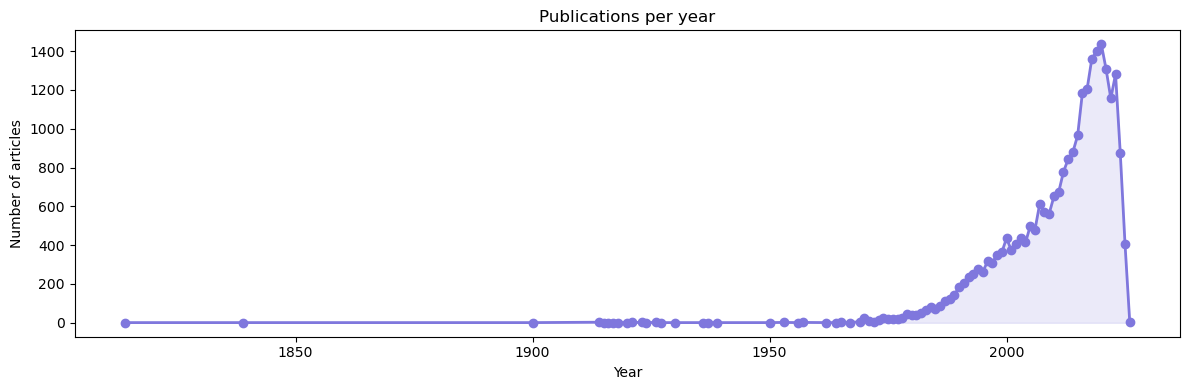

In [27]:
df['year'] = pd.to_numeric(df['year'], errors='coerce')  # force numeric, NaN if bad

yearly = df.groupby('year').size().reset_index(name='count')

plt.figure(figsize=(12, 4))
plt.plot(yearly['year'], yearly['count'], marker='o', linewidth=2, color='#7F77DD')
plt.fill_between(yearly['year'], yearly['count'], alpha=0.15, color='#7F77DD')
plt.title('Publications per year')
plt.xlabel('Year')
plt.ylabel('Number of articles')
plt.tight_layout()
plt.savefig('yearly_trend.png', dpi=150)
plt.show()

Citation stats:
count    25000.000000
mean        30.611400
std        270.161857
min          0.000000
25%          1.000000
50%          4.000000
75%         23.000000
max      28038.000000
Name: citations, dtype: float64

Median citations: 4.0
Papers with 0 citations: 6082
Papers with >100 citations: 1415


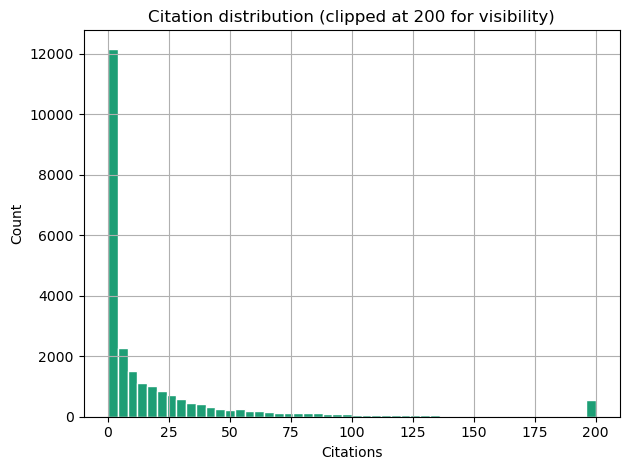

In [98]:

df['citations'] = pd.to_numeric(df['citations'], errors='coerce')

print("Citation stats:")
print(df['citations'].describe())
print(f"\nMedian citations: {df['citations'].median()}")
print(f"Papers with 0 citations: {(df['citations'] == 0).sum()}")
print(f"Papers with >100 citations: {(df['citations'] > 100).sum()}")

# Quick histogram
df['citations'].clip(upper=200).hist(bins=50, color='#1D9E75', edgecolor='white')
plt.title('Citation distribution (clipped at 200 for visibility)')
plt.xlabel('Citations')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('citation_dist.png', dpi=150)
plt.show()

In [99]:

def count_list_column(col_series, col_name, top_n=50):
  
    all_values = []
    
    for val in col_series.dropna():
        val = str(val).strip()
        # Try to parse as Python list
        try:
            import ast
            parsed = ast.literal_eval(val)
            if isinstance(parsed, list):
                all_values.extend([str(v).strip() for v in parsed])
            else:
                all_values.append(val)
        except:
            # If it's a plain string (comma separated), split it
            all_values.extend([v.strip() for v in val.split(',')])
            all_values.extend([v.strip() for v in val.split(';')])
            all_values.extend([v.strip() for v in val.split(' ')])
    
    counts = Counter(all_values)
    result = pd.DataFrame(counts.most_common(top_n), columns=[col_name, 'count'])
    return result

# Run for each column
for col in ['topics', 'concepts', 'domain', 'subfield', 'languages']:
    if col in df.columns:
        result = count_list_column(df[col], col)
        print(f"\n── Top values in '{col}' ──")
        print(result.to_string(index=False))


── Top values in 'topics' ──
                                topics  count
                                   and  52584
                                Gender  12357
                               Studies   7990
                               Gender,   6089
                              Studies;   5780
                              Feminism   5059
                            Historical   4509
                              Politics   3760
                             Feminism,   3172
                                    in   3101
Historical Gender and Feminism Studies   3034
                                 Media   3015
                             Education   3009
                               History   2934
                                Social   2805
    Gender Politics and Representation   2771
           Gender, Feminism, and Media   2526
                              Cultural   2176
                              American   2145
                             Political   2113
    

In [100]:
# Model Creation

In [31]:
df_model = df.copy()

print("working copy created.")

print("shape:", df_model.shape)


working copy created.
shape: (25000, 13)


In [32]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

# ── STEP A: TF-IDF ──────────────────────────────────────────────
tfidf = TfidfVectorizer(
    stop_words='english',    # ignore filler words
    max_features=5000,       # keep top 5000 most informative words
    ngram_range=(1, 2),      # single words AND two-word phrases
    sublinear_tf=True        # dampens the effect of very frequent words
)

title_matrix = tfidf.fit_transform(df_model["title"].astype(str).fillna(''))

print(f"TF-IDF matrix shape: {title_matrix.shape}")



TF-IDF matrix shape: (25000, 5000)


In [33]:

# ── STEP B: PCA ─────────────────────────────────────────────────

n_components = 1800
pca = PCA(n_components=n_components, random_state=42)
title_pca = pca.fit_transform(title_matrix.toarray())

explained = pca.explained_variance_ratio_.cumsum()

print(f"\nVariance explained by {n_components} PCA components: {explained[-1]*100:.1f}%")



Variance explained by 1800 PCA components: 76.2%


In [34]:
pca_cols = [f'pca_{i}' for i in range(n_components)]
title_pca_df = pd.DataFrame(title_pca, columns=pca_cols, index=df_model.index)

print(f"\nPCA DataFrame shape: {title_pca_df.shape}")


PCA DataFrame shape: (25000, 1800)


In [35]:
from sklearn.preprocessing import MultiLabelBinarizer
import ast


def parse_list_column(series):

    result = []
    for val in series:
        val = str(val).strip()
        if val == '' or val == 'nan':
            result.append([])
            continue
        try:
            parsed = ast.literal_eval(val)
            if isinstance(parsed, list):
                result.append([str(v).strip().lower() for v in parsed])
            else:
                result.append([str(parsed).strip().lower()])
        except:
            # Plain comma-separated string
            result.append([v.strip().lower() for v in val.split(',') if v.strip()])
            
    return result

# Columns to encode
encode_cols = ['topics', 'concepts', 'domain', 'subfield', 'languages']

mlb_dfs = []  # we'll collect each encoded DataFrame here

for col in encode_cols:
    if col not in df_model.columns:
        continue

    parsed = parse_list_column(df_model[col])

    mlb = MultiLabelBinarizer()
    encoded = mlb.fit_transform(parsed)

    # Prefix column names so we know which column they came from
    col_names = [f'{col}__{tag}' for tag in mlb.classes_]
    encoded_df = pd.DataFrame(encoded, columns=col_names, index=df_model.index)

    mlb_dfs.append(encoded_df)
    print(f"  '{col}': {len(mlb.classes_)} unique tags → {encoded.shape[1]} binary columns")

# Combine all encoded columns
mlb_combined = pd.concat(mlb_dfs, axis=1)
print(f"\nAll encoded tags combined shape: {mlb_combined.shape}")

  'topics': 14679 unique tags → 14679 binary columns
  'concepts': 22108 unique tags → 22108 binary columns
  'domain': 4 unique tags → 4 binary columns
  'subfield': 164 unique tags → 164 binary columns
  'languages': 48 unique tags → 48 binary columns

All encoded tags combined shape: (25000, 37003)


In [36]:
from sklearn.preprocessing import MinMaxScaler

# ── WHY normalize? ───────────────────────────────────────────────
# 'citations' might range from 0 to 50,000.
# 'year' ranges from 1990 to 2024.
# If we feed both into KMeans raw, citations will DOMINATE the
# distance calculations just because its numbers are bigger.
# MinMaxScaler brings everything to [0, 1] so all features
# contribute equally.

numeric_cols = ['year', 'citations']
numeric_cols = [c for c in numeric_cols if c in df_model.columns]

scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(df_model[numeric_cols])
scaled_df = pd.DataFrame(
    scaled_values,
    columns=[f'{c}_scaled' for c in numeric_cols],
    index=df_model.index
)

print("Scaled numeric columns:")
print(scaled_df.describe().round(3))

# Also keep openaccess (already 0/1, no scaling needed)
oa_df = df_model[['openaccess']].copy()

Scaled numeric columns:
       year_scaled  citations_scaled
count    25000.000         25000.000
mean         0.931             0.001
std          0.052             0.010
min          0.000             0.000
25%          0.901             0.000
50%          0.948             0.000
75%          0.972             0.001
max          1.000             1.000


In [37]:
# ── WHY ─────────────────────────────────────────────────────────
# We now have 4 blocks of features:
#   A) PCA components from titles    (50 columns)
#   B) Encoded topics/concepts/etc   (many 0/1 columns)
#   C) Scaled numeric columns        (2 columns: year, citations)
#   D) openaccess                    (1 column)
#
# We concatenate them all horizontally into ONE matrix.
# This is the matrix KMeans will cluster on.

journals_model_final = pd.concat([
    title_pca_df,    # A
    mlb_combined,    # B
    scaled_df,       # C
    oa_df            # D
], axis=1)

print("\n Final model matrix shape:", journals_model_final.shape)
print("Columns (first 10):", journals_model_final.columns[:10].tolist())

# Sanity check: no NaNs anywhere
assert journals_model_final.isnull().sum().sum() == 0, " NaNs remain — check parsing!"
print(" No NaN values in model matrix.")

# Save the index-aligned original df for display later in Streamlit
# Use intersection to only get indices that exist in both dataframes
common_indices = journals_model_final.index.intersection(df.index)
journals_display = df.loc[common_indices].copy()
# Reindex journals_model_final to match the common indices
journals_model_final = journals_model_final.loc[common_indices]

print(f" Display dataframe aligned and ready. Shape: {journals_display.shape}")
print(f" Model matrix updated to match. Shape: {journals_model_final.shape}")


 Final model matrix shape: (25000, 38806)
Columns (first 10): ['pca_0', 'pca_1', 'pca_2', 'pca_3', 'pca_4', 'pca_5', 'pca_6', 'pca_7', 'pca_8', 'pca_9']
 No NaN values in model matrix.
 Display dataframe aligned and ready. Shape: (25000, 13)
 Model matrix updated to match. Shape: (25000, 38806)


In [104]:
import joblib

# Save the model matrix
journals_model_final.to_csv('../1_sources/journals_model_final.csv', index=True)

# Save the transformers — we need them later in Streamlit
# to transform NEW user queries the same way
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')
joblib.dump(pca, 'pca_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# Save display data
journals_display.to_csv('journals_display2.csv', index=True)
df.to_csv('journals_display.csv', index=True)

print(" All files saved:")
print("   df_model_final.csv  ← model input")
print("   journals_display.csv      ← for showing results in the app")
print("   tfidf_vectorizer.pkl      ← to transform new queries")
print("   pca_model.pkl             ← to compress new queries")
print("   scaler.pkl                ← to scale new queries")

 All files saved:
   df_model_final.csv  ← model input
   journals_display.csv      ← for showing results in the app
   tfidf_vectorizer.pkl      ← to transform new queries
   pca_model.pkl             ← to compress new queries
   scaler.pkl                ← to scale new queries


In [39]:
joblib.dump(mlb, 'mlb.pkl')  # Save the topic encoder

['mlb.pkl']